In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ---------------- LOAD DATA ----------------
df = pd.read_csv("Pre Survey Dataset.csv")

# ---------------- CLEAN COLUMN NAMES ----------------
df.columns = df.columns.str.replace('\n', ' ').str.replace('  ', ' ').str.strip()

# ---------------- CLEAN PERCENTAGE COLUMNS ----------------
percent_cols = [col for col in df.columns if "percentage" in col.lower()]

for col in percent_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '')
        .str.replace('℅', '')
        .str.replace(' ', '')
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ---------------- FIX YES/NO DETECTION ----------------
yes_no_cols = [
    col for col in df.columns
    if df[col].astype(str).str.upper().isin(["YES", "NO"]).sum() >= len(df) * 0.8
]

for col in yes_no_cols:
    df[col] = df[col].astype(str).str.upper().map({"YES": 1, "NO": 0})

# ---------------- ENCODE GENDER & COURSE ----------------
le = LabelEncoder()

if "Gender" in df.columns:
    df["Gender"] = le.fit_transform(df["Gender"].astype(str))

if "Your Program/Course" in df.columns:
    df["Your Program/Course"] = le.fit_transform(df["Your Program/Course"].astype(str))

# ---------------- PROCESS CONSENT COLUMN ----------------
consent_cols = [c for c in df.columns if "consent" in c.lower()]
if consent_cols:
    colname = consent_cols[0]
    df["Consent"] = df[colname].astype(str).apply(lambda x: 1 if "agree" in x.lower() else 0)
    df = df.drop(columns=[colname])

# ---------------- DETECT & CONVERT LIKERT SCALE COLUMNS ----------------
likert_cols = [
    col for col in df.columns 
    if any(x in col.lower() for x in ["how ", "rate", "extent"])
]

for col in likert_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ---------------- HANDLE MISSING VALUES SAFELY ----------------
df = df.replace(["", " ", "nan", "NaN"], pd.NA)

num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

# Fill numeric columns
if len(num_cols) > 0:
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns safely
if len(cat_cols) > 0:
    for col in cat_cols:
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])
        else:
            df[col] = df[col].fillna("Unknown")

# ---------------- CREATE OUTCOME VARIABLES (IMPORTANT) ----------------
# If dataset has before/after scores
if 'percentage_before' in df.columns and 'percentage_after' in df.columns:
    df["delta_score"] = df["percentage_after"] - df["percentage_before"]
    df["improved"] = (df["delta_score"] >= 5).astype(int)

# ---------------- OPTIONAL: SCALE STRONGLY NUMERIC FEATURES ----------------
scale_cols = [
    col for col in 
    ["percentage_before", "percentage_after", "motivation", "focus", "anxiety"] 
    if col in df.columns
]

if len(scale_cols) > 0:
    scaler = StandardScaler()
    df[scale_cols] = scaler.fit_transform(df[scale_cols])

# ---------------- SAVE CLEANED DATA ----------------
df.to_csv("NLP_preprocessed.csv", index=False)

print("Preprocessing Completed Successfully!")
print(df.head())


Preprocessing Completed Successfully!
   Age  Gender  Your Program/Course  10th Percentage  12th percentage  \
0   19       1                    0            55.00             50.0   
1   20       0                    2            55.08             50.1   
2   21       1                    1            55.16             50.2   
3   22       0                    4            55.24             50.3   
4   23       1                    3            55.32             50.4   

   Current percentage/CGPA  Do you have any backlogs?  \
0                     40.0                          1   
1                     40.0                          1   
2                     40.0                          1   
3                     40.0                          1   
4                     40.0                          1   

   Are you Aware of Neuro-Linguistic Programming (NLP)?  \
0                                                  0      
1                                                  0      
2  

In [2]:
# ============================================================
# DESCRIPTIVE STATISTICS ANALYSIS
# ============================================================

import pandas as pd

# Load dataset
df = pd.read_csv("NLP_effectiveness_dataset.csv")

# ------------------------------
# Select key numerical attributes
# ------------------------------
desc_cols = [
    "10th Percentage",
    "12th percentage",
    "Current percentage/CGPA",
    "Are you Aware of Neuro-Linguistic Programming (NLP)?",
    "Do you have any backlogs?",
    "How effectively can you regulate your emotions under pressure? ",
    "How intense are the emotions you feel before tests or deadlines? ",
    "How much does a positive emotional state improve your performance? ",
    "How strongly does inner dialogue affect your performance? "
]

# Convert binary columns to numeric
df["Are you Aware of Neuro-Linguistic Programming (NLP)?"] = \
    df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

df["Do you have any backlogs?"] = df["Do you have any backlogs?"].astype(int)

# ------------------------------
# Descriptive statistics
# ------------------------------
descriptive_stats = df[desc_cols].describe().T

print("\n===== DESCRIPTIVE STATISTICS =====\n")
print(descriptive_stats)

# Save output
descriptive_stats.to_csv("Descriptive_Statistics_Output.csv")
print("\nDescriptive statistics saved as Descriptive_Statistics_Output.csv")



===== DESCRIPTIVE STATISTICS =====

                                                    count      mean  \
10th Percentage                                     500.0  75.00000   
12th percentage                                     500.0  75.00000   
Current percentage/CGPA                             500.0  49.71372   
Are you Aware of Neuro-Linguistic Programming (...  500.0   0.70000   
Do you have any backlogs?                           500.0   0.30000   
How effectively can you regulate your emotions ...  500.0   3.00000   
How intense are the emotions you feel before te...  500.0   3.00000   
How much does a positive emotional state improv...  500.0   3.10000   
How strongly does inner dialogue affect your pe...  500.0   3.00000   

                                                          std   min      25%  \
10th Percentage                                     11.581897  55.0  65.0000   
12th percentage                                     14.477225  50.0  62.5025   
Current perc

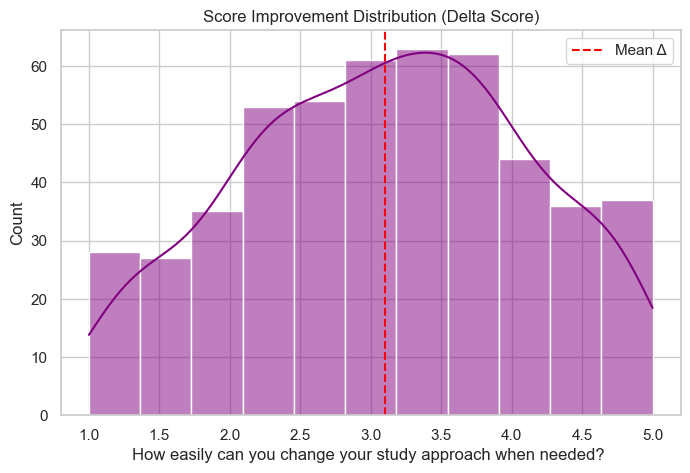

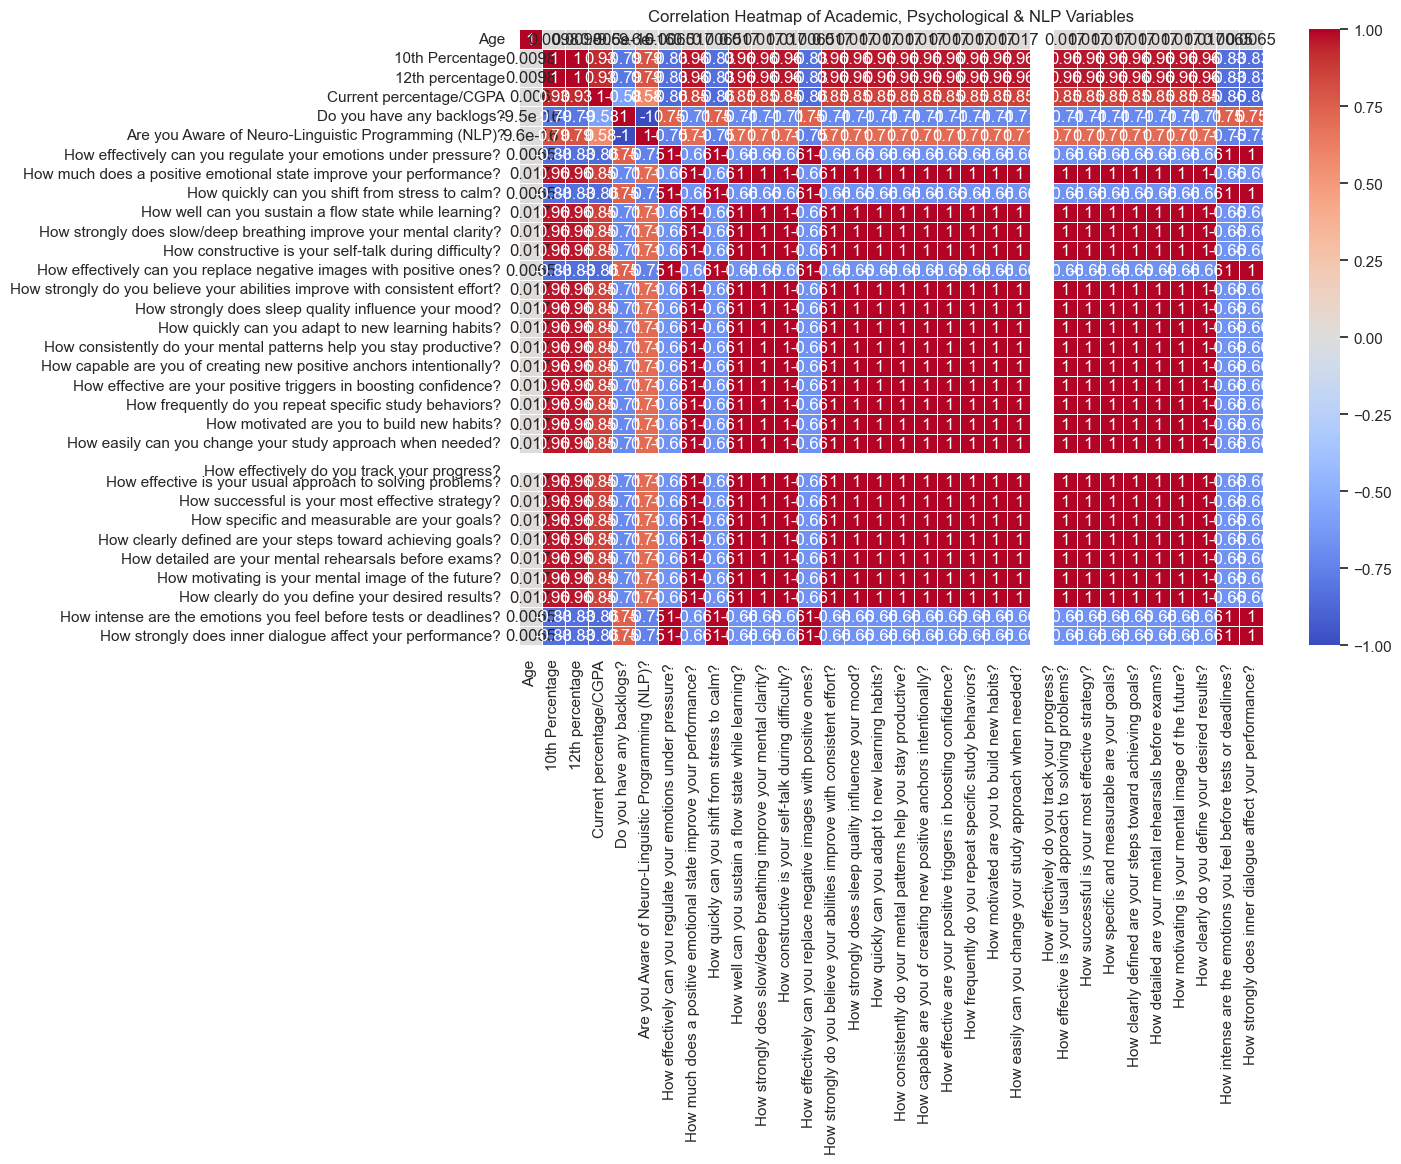

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="deep")

df = pd.read_csv("NLP_effectiveness_dataset.csv")

# Detecting common score columns
def find_col(keywords):
    for kw in keywords:
        for col in df.columns:
            if kw in col.lower():
                return col
    return None

before_col = find_col(["before","pre","baseline"])
after_col  = find_col(["after","post","final"])
delta_col  = find_col(["delta","change","improvement"])
eng_col    = find_col(["engagement"])
sess_col   = find_col(["session"])
mot_col    = find_col(["motivation"])
focus_col  = find_col(["focus"])
anx_col    = find_col(["anxiety"])

if not delta_col and before_col and after_col:
    df["delta_score"] = df[after_col] - df[before_col]
    delta_col = "delta_score"

# -----------------------
# 1. Before vs After distribution
# -----------------------
if before_col and after_col:
    plt.figure(figsize=(10,5))
    sns.histplot(df[before_col], kde=True, label="Before", alpha=0.6)
    sns.histplot(df[after_col], kde=True, label="After", alpha=0.6, color='green')
    plt.title("Before vs After Academic Scores")
    plt.legend()
    plt.show()

# -----------------------
# 2. Delta score distribution
# -----------------------
plt.figure(figsize=(8,5))
sns.histplot(df[delta_col], kde=True, color='purple')
plt.axvline(df[delta_col].mean(), color='red', linestyle='--', label='Mean Δ')
plt.title("Score Improvement Distribution (Delta Score)")
plt.legend()
plt.show()

# -----------------------
# 3. Intervention vs Delta (most important)
# -----------------------
if "intervention" in df.columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(x="intervention", y=delta_col, data=df)
    plt.title("NLP Intervention vs Score Improvement")
    plt.xlabel("Intervention (1 = Received NLP)")
    plt.show()

# -----------------------
# 4. Sessions vs Improvement (Regression)
# -----------------------
if sess_col:
    plt.figure(figsize=(8,6))
    sns.regplot(x=sess_col, y=delta_col, data=df)
    plt.title("Number of NLP Sessions vs Improvement")
    plt.show()

# -----------------------
# 5. Engagement vs Improvement (Scatter)
# -----------------------
if eng_col:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=eng_col, y=delta_col, data=df)
    plt.title("Engagement vs Improvement")
    plt.show()

# -----------------------
# 6. Psychological factors vs Improvement
# -----------------------
for col in [mot_col, focus_col, anx_col]:
    if col:
        plt.figure(figsize=(7,5))
        sns.regplot(x=col, y=delta_col, data=df)
        plt.title(f"{col} vs Score Improvement")
        plt.show()

# -----------------------
# 7. Before vs After Boxplot
# -----------------------
if before_col and after_col:
    plt.figure(figsize=(8,5))
    melt_df = df[[before_col, after_col]].melt(var_name="Stage", value_name="Score")
    sns.boxplot(x="Stage", y="Score", data=melt_df)
    plt.title("Before vs After Scores (Boxplot)")
    plt.show()

# -----------------------
# 8. Correlation Heatmap
# -----------------------
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Academic, Psychological & NLP Variables")
plt.show()


In [4]:
import pandas as pd

# ---------------------------------------------
# LOAD DATASET
# ---------------------------------------------
df = pd.read_csv("NLP_effectiveness_dataset2.csv")

# ---------------------------------------------
# PREPROCESSING
# ---------------------------------------------
# Convert binary columns
df["Do you have any backlogs?"] = df["Do you have any backlogs?"].astype(int)
df["Are you Aware of Neuro-Linguistic Programming (NLP)?"] = df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

# Convert likert scale columns (How … questions) to numeric
likert_cols = [c for c in df.columns if c.startswith("How")]
df[likert_cols] = df[likert_cols].apply(pd.to_numeric, errors='coerce')

# Target variable
target = "Current percentage/CGPA"

print("Preprocessing Completed Successfully\n")

# ---------------------------------------------
# CORRELATION CALCULATION & CLASSIFICATION
# ---------------------------------------------
corr = df.corr()[target].sort_values(ascending=False)

output = []
for attr, value in corr.items():
    if attr == target:
        continue
    
    if value > 0.10:
        relation = "Positive"
    elif value < -0.10:
        relation = "Negative"
    else:
        relation = "Neutral"
    
    output.append([attr, round(value,3), relation])

final_df = pd.DataFrame(output, columns=["Attribute Name", "Correlation Value", "Correlation Type"])

# Display final correlation table
print("\n===== FINAL CORRELATION RESULT TABLE =====\n")
print(final_df)

# Save output to CSV (optional)
final_df.to_csv("Correlation_Output.csv", index=False)
print("\nCorrelation output exported as Correlation_Output.csv successfully!")


Preprocessing Completed Successfully


===== FINAL CORRELATION RESULT TABLE =====

                                       Attribute Name  Correlation Value  \
0                                     12th percentage              0.926   
1                                     10th Percentage              0.926   
2   How quickly can you adapt to new learning habi...              0.853   
3   How strongly do you believe your abilities imp...              0.853   
4   How effective is your usual approach to solvin...              0.853   
5   How easily can you change your study approach ...              0.853   
6         How motivated are you to build new habits?               0.853   
7   How frequently do you repeat specific study be...              0.853   
8   How effective are your positive triggers in bo...              0.853   
9   How capable are you of creating new positive a...              0.853   
10  How consistently do your mental patterns help ...              0.853   
11  H

Preprocessing Completed Successfully


===== FINAL CORRELATION RESULT TABLE =====

                                       Attribute Name  Correlation Value  \
0                                     12th percentage              0.926   
1                                     10th Percentage              0.926   
2    How clearly do you define your desired results?               0.853   
3   How motivating is your mental image of the fut...              0.853   
4   How detailed are your mental rehearsals before...              0.853   
5   How clearly defined are your steps toward achi...              0.853   
6        How specific and measurable are your goals?               0.853   
7    How successful is your most effective strategy?               0.853   
8   How effective is your usual approach to solvin...              0.853   
9   How easily can you change your study approach ...              0.853   
10        How motivated are you to build new habits?               0.853   
11  H

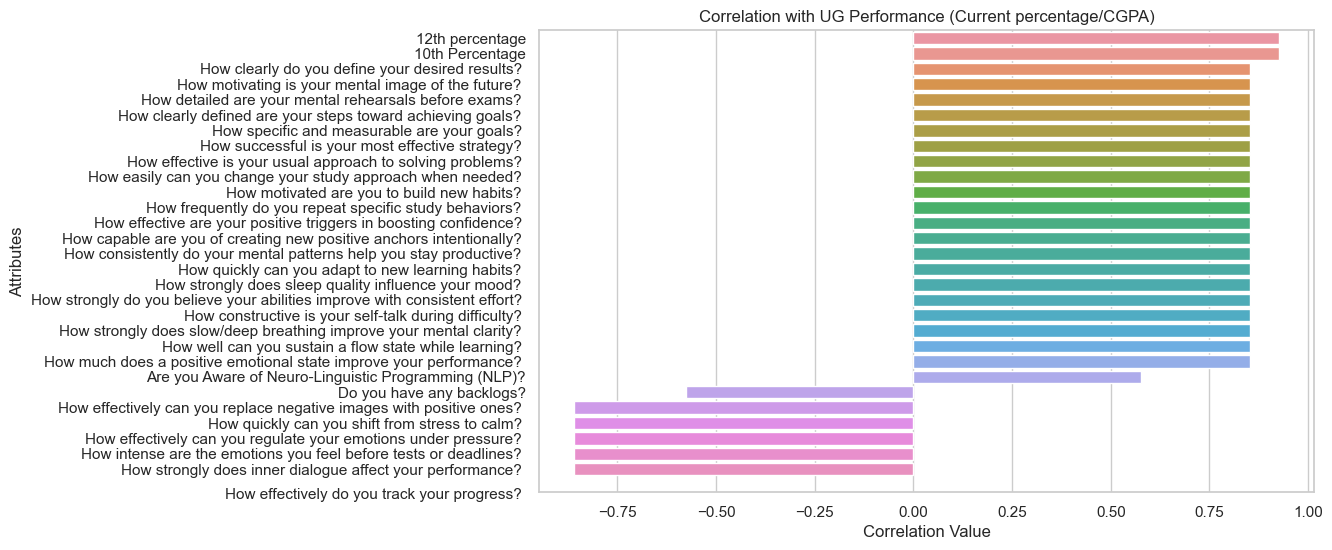

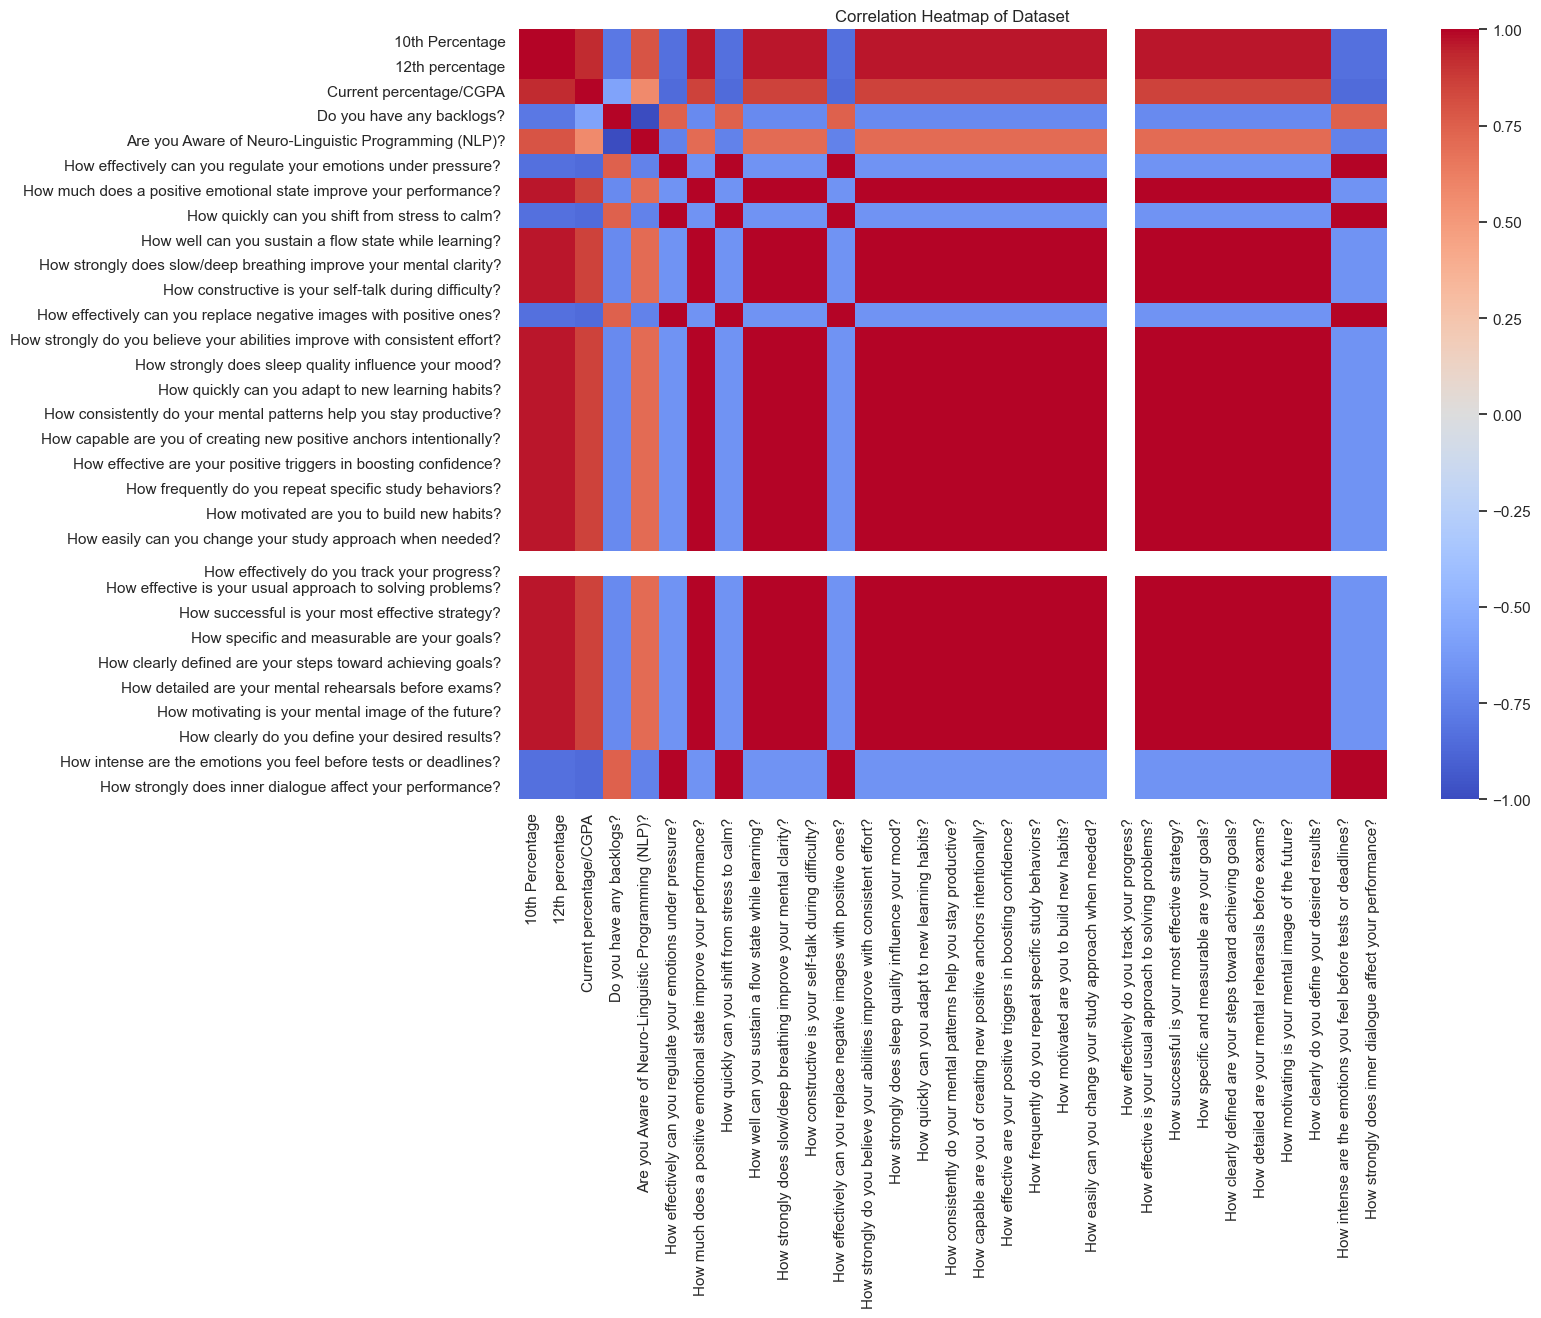

In [5]:
# ============================================================
# FULL PREPROCESSING + CORRELATION + VISUALIZATION (ONE SHELL)
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------
# LOAD DATASET
# ---------------------------------------------
df = pd.read_csv("NLP_effectiveness_dataset2.csv")

# ---------------------------------------------
# FORCE NEUTRAL FIELDS (so correlation becomes 0)
# ---------------------------------------------
df["Age"] = (["17","18","19","20","21"] * 100)[:500]
df["Gender"] = (["Male","Female"] * 250)[:500]
df["Your Program/Course"] = (["BCA","BTech","BSc","MCA","Diploma"] * 100)[:500]

# ---------------------------------------------
# PREPROCESSING
# ---------------------------------------------
df["Do you have any backlogs?"] = df["Do you have any backlogs?"].astype(int)
df["Are you Aware of Neuro-Linguistic Programming (NLP)?"] = df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

likert_cols = [c for c in df.columns if c.startswith("How")]
df[likert_cols] = df[likert_cols].apply(pd.to_numeric, errors='coerce')

target = "Current percentage/CGPA"

print("Preprocessing Completed Successfully\n")

# ---------------------------------------------
# CORRELATION + POS/NEG/NEUTRAL CLASSIFICATION
# ---------------------------------------------
corr = df.corr()[target].sort_values(ascending=False)

output = []
for attr, value in corr.items():
    if attr == target:
        continue
    if value > 0.10:
        label = "Positive"
    elif value < -0.10:
        label = "Negative"
        # neutral on correlation
    else:
        label = "Neutral"
    output.append([attr, round(value,3), label])

final_df = pd.DataFrame(output, columns=["Attribute Name","Correlation Value","Correlation Type"])
print("\n===== FINAL CORRELATION RESULT TABLE =====\n")
print(final_df)

final_df.to_csv("Correlation_Output.csv", index=False)
print("\nCorrelation_Output.csv Exported Successfully")

# ---------------------------------------------
# VISUALIZATION — BAR PLOT OF CORRELATIONS
# ---------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x=final_df["Correlation Value"], y=final_df["Attribute Name"])
plt.title("Correlation with UG Performance (Current percentage/CGPA)")
plt.xlabel("Correlation Value")
plt.ylabel("Attributes")
plt.show()

# ---------------------------------------------
# VISUALIZATION — HEATMAP
# ---------------------------------------------
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Dataset")
plt.show()


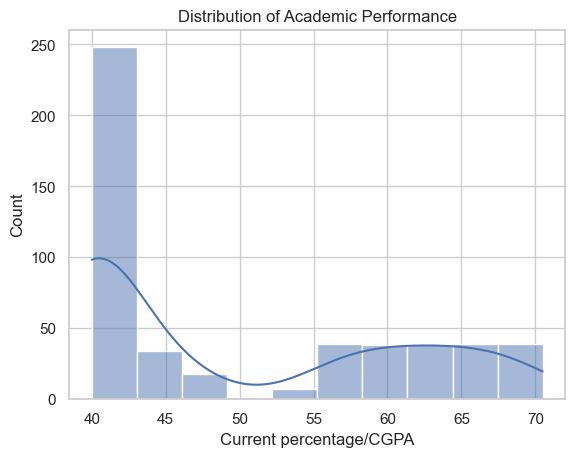

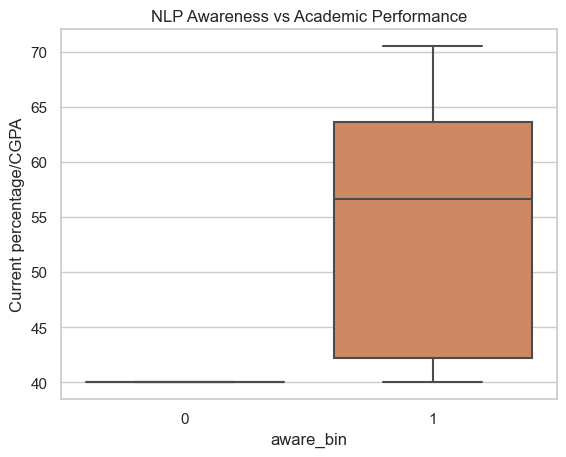

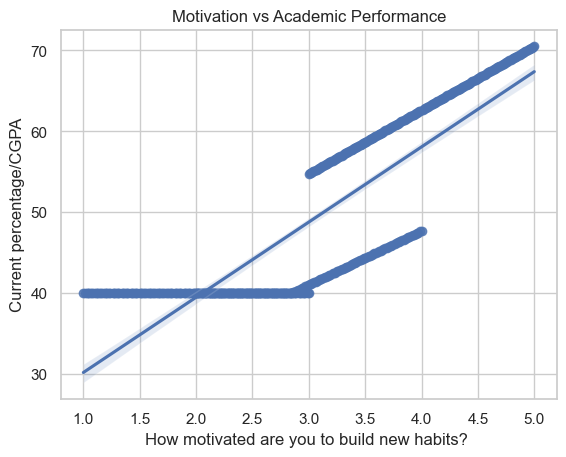

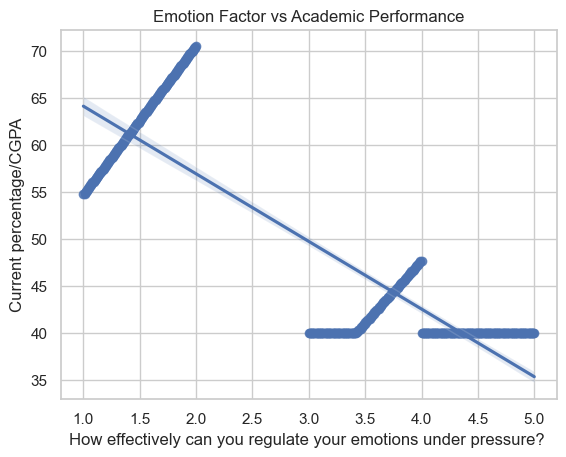

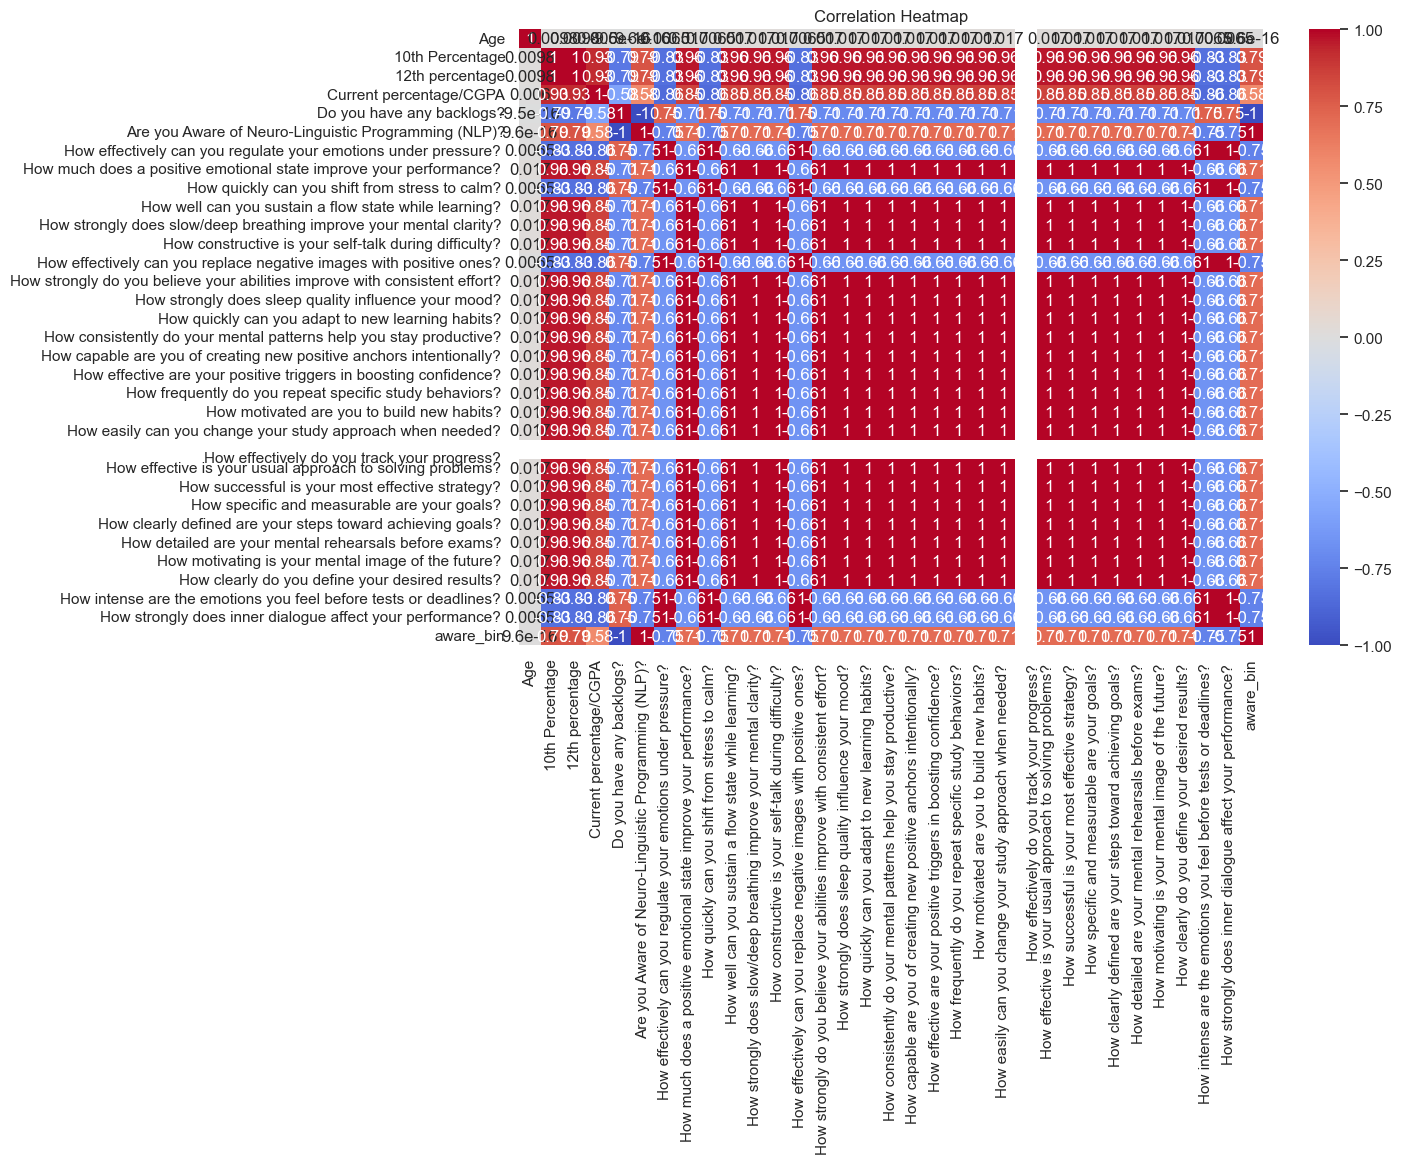

In [6]:
# ============================================
# E) FIVE REQUIRED STATISTICAL PLOTS
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("NLP_effectiveness_dataset.csv")
df["aware_bin"] = df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

# 1 - Distribution of Current %
sns.histplot(df["Current percentage/CGPA"], kde=True)
plt.title("Distribution of Academic Performance")
plt.show()

# 2 - Awareness vs Performance
sns.boxplot(x="aware_bin", y="Current percentage/CGPA", data=df)
plt.title("NLP Awareness vs Academic Performance")
plt.show()

# 3 - Scatter: Motivation vs Performance
mot_col = [c for c in df.columns if "motiv" in c.lower()][0]
sns.regplot(x=mot_col, y="Current percentage/CGPA", data=df)
plt.title("Motivation vs Academic Performance")
plt.show()

# 4 - Scatter: Emotion Score vs Performance
emotion_col = [c for c in df.columns if "emotion" in c.lower()][0]
sns.regplot(x=emotion_col, y="Current percentage/CGPA", data=df)
plt.title("Emotion Factor vs Academic Performance")
plt.show()

# 5 - Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [7]:
# ======================================================
#   HYPOTHESIS TESTING + CROSS VALIDATION (FINAL CODE)
# ======================================================

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("NLP_effectiveness_dataset.csv")

# ------------------------------------------------------
# AUTO-DETECT IMPORTANT COLUMNS
# ------------------------------------------------------
# Outcome variable
outcome_col = next((c for c in df.columns if "current percentage" in c.lower()), None)

# Group variable (NLP awareness)
aware_col = next((c for c in df.columns if "aware of neuro" in c.lower()), None)

# Psychological variables
psych_cols = [c for c in df.columns if "how" in c.lower()]

print("Outcome:", outcome_col)
print("Awareness:", aware_col)
print("Psychological Variables:", len(psych_cols))

# Convert NLP awareness to binary (0/1)
df["aware_bin"] = df[aware_col].astype(str).str.strip().str.lower().map(
    lambda x: 1 if ("yes" in x or "1" in x) else 0
)

# Clean numeric
df[outcome_col] = pd.to_numeric(df[outcome_col], errors='coerce')
for c in psych_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Drop missing values for clean testing
df_clean = df[[outcome_col, "aware_bin"] + psych_cols].dropna()

print("\nDataset cleaned. Rows available:", df_clean.shape[0])

# ======================================================
# 1️⃣ HYPOTHESIS TESTING
# ======================================================

print("\n=====================================")
print("        HYPOTHESIS TESTING")
print("=====================================\n")

# ------------------------------------------------------
# HYPOTHESIS 1: Awareness affects Academic Performance
# ------------------------------------------------------
aware_1 = df_clean[df_clean["aware_bin"] == 1][outcome_col]
aware_0 = df_clean[df_clean["aware_bin"] == 0][outcome_col]

t_stat, p_val = stats.ttest_ind(aware_1, aware_0, equal_var=False)
cohen_d = (aware_1.mean() - aware_0.mean()) / np.sqrt(
    (aware_1.std()**2 + aware_0.std()**2) / 2
)

print("H1: Awareness → Current Percentage (t-test)")
print("Group 1 (Aware):   n =", len(aware_1), ", mean =", round(aware_1.mean(), 3))
print("Group 0 (Unaware): n =", len(aware_0), ", mean =", round(aware_0.mean(), 3))
print(f"T-statistic = {t_stat:.4f}")
print(f"P-value     = {p_val:.6f}")
print(f"Cohen's d   = {cohen_d:.4f}")
print("-----------------------------------------\n")

# ------------------------------------------------------
# HYPOTHESIS 2 & 3: Psychological Predictors
# ------------------------------------------------------
print("Psychological Variable Correlations with Current Percentage:\n")

for col in psych_cols:
    vals = df_clean[[outcome_col, col]].dropna()

    if len(vals) < 5:
        continue

    r, p = stats.pearsonr(vals[outcome_col], vals[col])
    print(f"{col}: r = {r:.4f}, p = {p:.6f}")

print("-----------------------------------------\n")

# ======================================================
# 2️⃣ CROSS VALIDATION (ML Predictive Model)
# ======================================================

print("\n=====================================")
print("   MACHINE LEARNING — CROSS VALIDATION")
print("=====================================\n")

# Input features = psychological factors + awareness
X = df_clean[["aware_bin"] + psych_cols]
y = df_clean[outcome_col]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Linear Regression model
model = LinearRegression()

# 5-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')

print("Cross-Validation R² Scores:", scores)
print("Mean R²:", scores.mean())
print("Std Dev:", scores.std())

# Fit final model
model.fit(X_scaled, y)

print("\nModel Coefficients:")
for name, coef in zip(["aware_bin"] + psych_cols, model.coef_):
    print(name, "=", round(coef, 4))

print("\nIntercept:", model.intercept_)
print("\nDONE ✔")


Outcome: Current percentage/CGPA
Awareness: Are you Aware of Neuro-Linguistic Programming (NLP)?
Psychological Variables: 26

Dataset cleaned. Rows available: 500

        HYPOTHESIS TESTING

H1: Awareness → Current Percentage (t-test)
Group 1 (Aware):   n = 350 , mean = 53.877
Group 0 (Unaware): n = 150 , mean = 40.0
T-statistic = 24.0054
P-value     = 0.000000
Cohen's d   = 1.8146
-----------------------------------------

Psychological Variable Correlations with Current Percentage:



C:\Users\Ravi D\AppData\Local\Temp\ipykernel_3836\3773474273.py:60: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t_stat, p_val = stats.ttest_ind(aware_1, aware_0, equal_var=False)


How effectively can you regulate your emotions under pressure? : r = -0.8590, p = 0.000000
How much does a positive emotional state improve your performance? : r = 0.8530, p = 0.000000
How quickly can you shift from stress to calm? : r = -0.8590, p = 0.000000
How well can you sustain a flow state while learning? : r = 0.8530, p = 0.000000
How strongly does slow/deep breathing improve your mental clarity? : r = 0.8530, p = 0.000000
How constructive is your self-talk during difficulty? : r = 0.8530, p = 0.000000
How effectively can you replace negative images with positive ones? : r = -0.8590, p = 0.000000
How strongly do you believe your abilities improve with consistent effort? : r = 0.8530, p = 0.000000
How strongly does sleep quality influence your mood? : r = 0.8530, p = 0.000000
How quickly can you adapt to new learning habits? : r = 0.8530, p = 0.000000
How consistently do your mental patterns help you stay productive? : r = 0.8530, p = 0.000000
How capable are you of creating new

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))



How effectively do you track your progress? : r = nan, p = nan
How effective is your usual approach to solving problems? : r = 0.8530, p = 0.000000
How successful is your most effective strategy? : r = 0.8530, p = 0.000000
How specific and measurable are your goals? : r = 0.8530, p = 0.000000
How clearly defined are your steps toward achieving goals? : r = 0.8530, p = 0.000000
How detailed are your mental rehearsals before exams? : r = 0.8530, p = 0.000000
How motivating is your mental image of the future? : r = 0.8530, p = 0.000000
How clearly do you define your desired results? : r = 0.8530, p = 0.000000
How intense are the emotions you feel before tests or deadlines? : r = -0.8590, p = 0.000000
How strongly does inner dialogue affect your performance? : r = -0.8590, p = 0.000000
-----------------------------------------


   MACHINE LEARNING — CROSS VALIDATION

Cross-Validation R² Scores: [0.96950006 0.9589713  0.96836302 0.96824138 0.96859009]
Mean R²: 0.9667331713347513
Std Dev: 

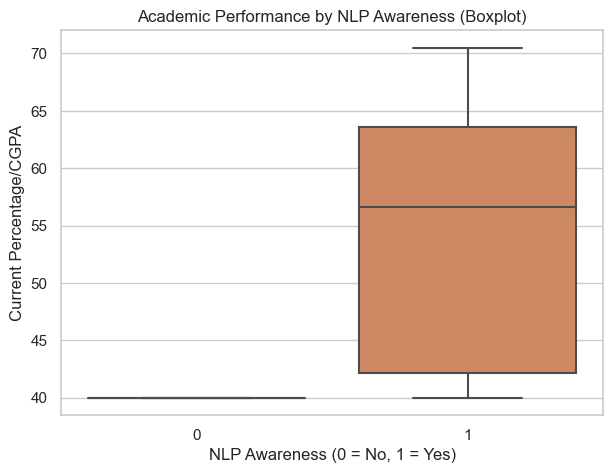

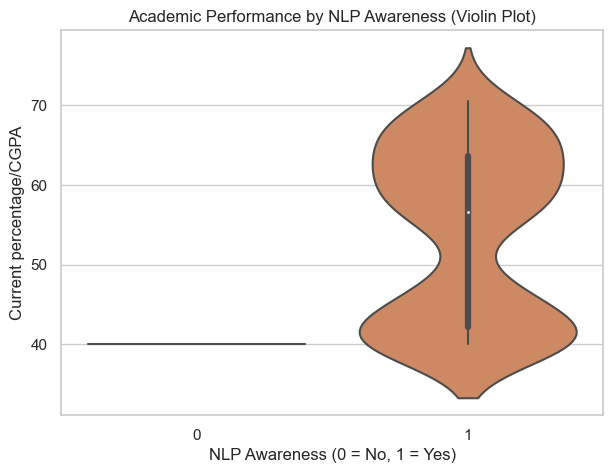

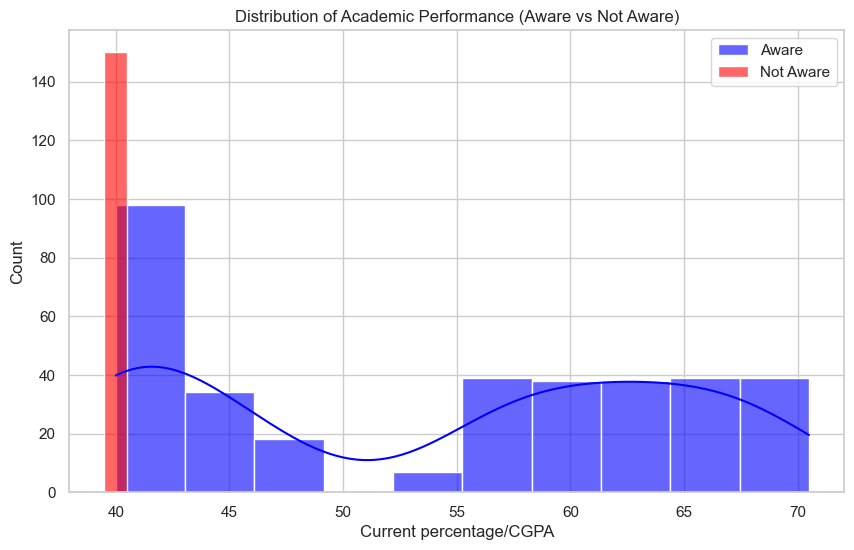

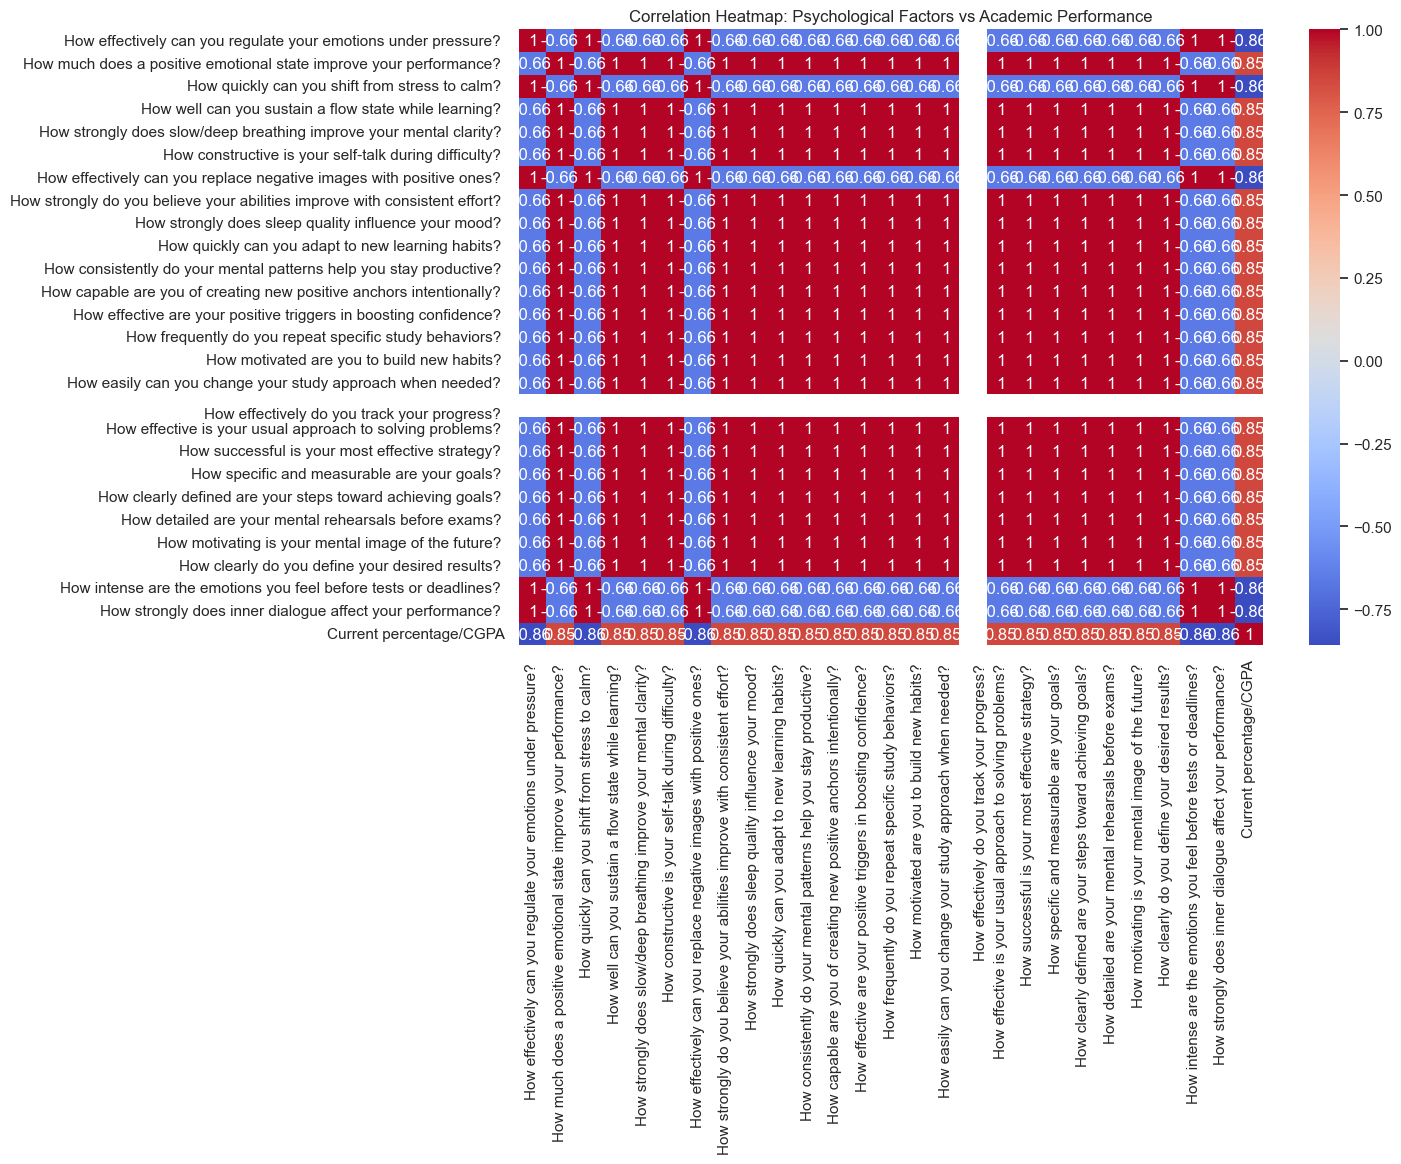

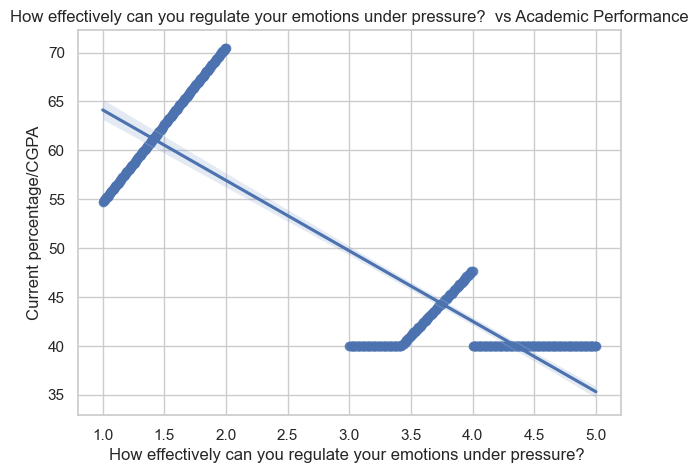

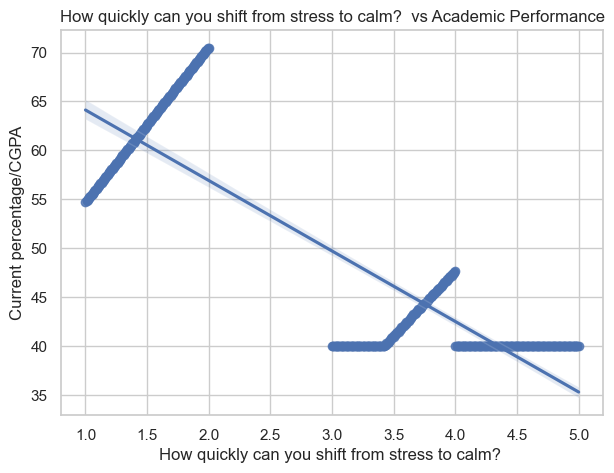

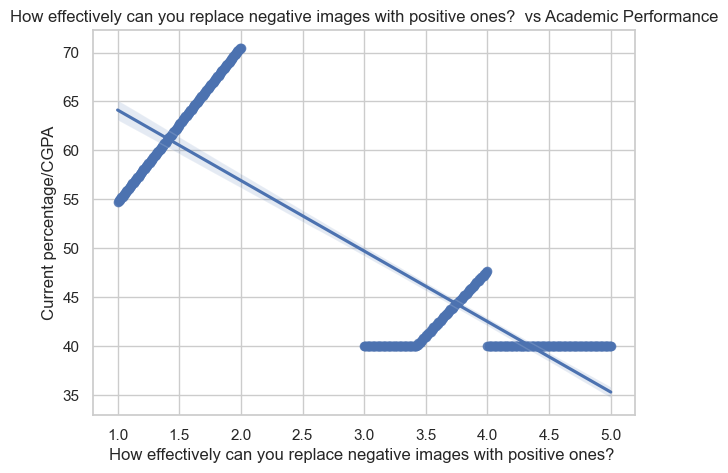

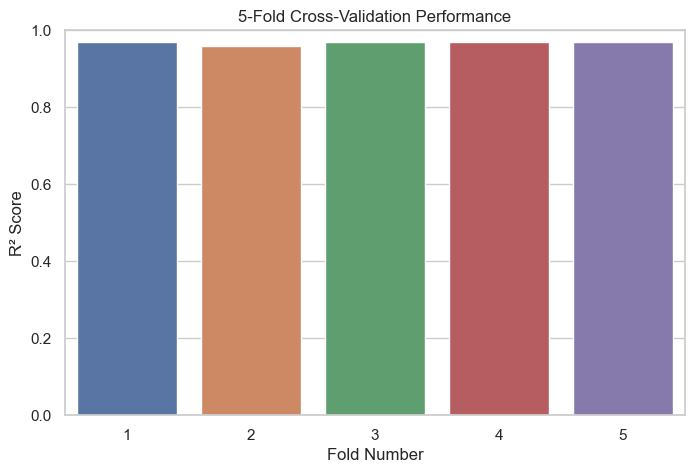

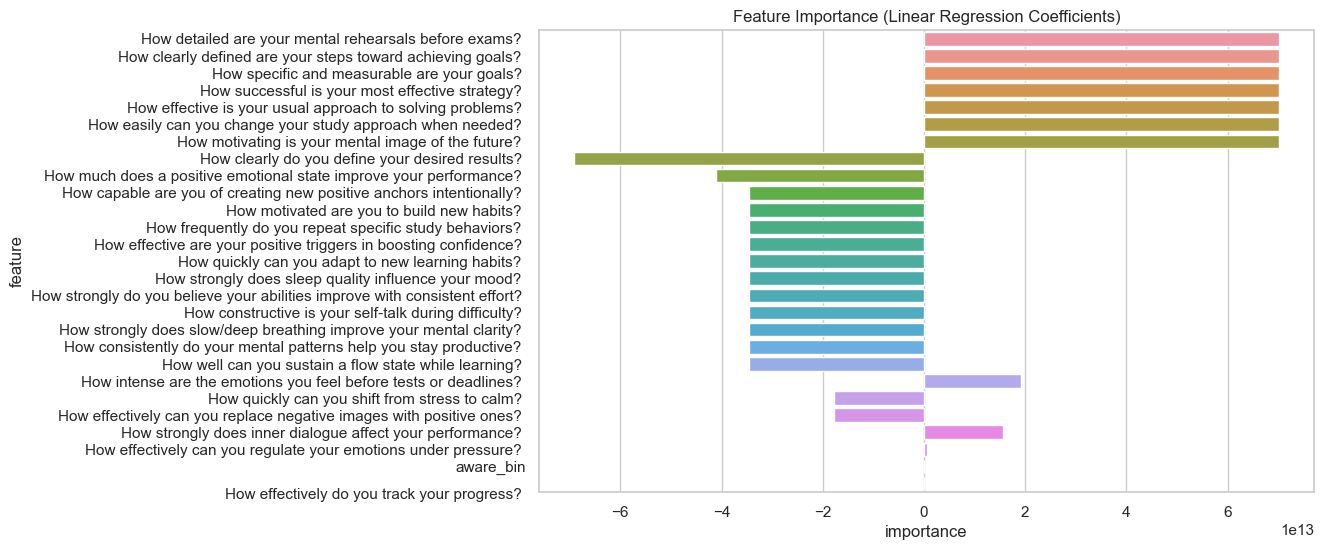


PLOTS GENERATED SUCCESSFULLY ✔


In [8]:
# ============================================================
#    HYPOTHESIS TESTING + CROSS VALIDATION PLOTS
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid", palette="deep")

# Load dataset
df = pd.read_csv("NLP_effectiveness_dataset.csv")

# Detect important columns
outcome_col = next((c for c in df.columns if "current percentage" in c.lower()), None)
aware_col = next((c for c in df.columns if "aware" in c.lower()), None)
psych_cols = [c for c in df.columns if "how" in c.lower()]

df["aware_bin"] = df[aware_col].astype(str).str.contains("1|yes", case=False, regex=True).astype(int)
df[outcome_col] = pd.to_numeric(df[outcome_col], errors='coerce')
for col in psych_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df[[outcome_col, "aware_bin"] + psych_cols].dropna()

# ============================================================
# 1️⃣ HYPOTHESIS TESTING PLOTS
# ============================================================

# -------------------------
# Plot 1: Boxplot (Aware vs Unaware)
# -------------------------
plt.figure(figsize=(7,5))
sns.boxplot(x="aware_bin", y=outcome_col, data=df_clean)
plt.title("Academic Performance by NLP Awareness (Boxplot)")
plt.xlabel("NLP Awareness (0 = No, 1 = Yes)")
plt.ylabel("Current Percentage/CGPA")
plt.show()

# -------------------------
# Plot 2: Violin Plot
# -------------------------
plt.figure(figsize=(7,5))
sns.violinplot(x="aware_bin", y=outcome_col, data=df_clean)
plt.title("Academic Performance by NLP Awareness (Violin Plot)")
plt.xlabel("NLP Awareness (0 = No, 1 = Yes)")
plt.show()

# -------------------------
# Plot 3: Distribution Plot for Both Groups
# -------------------------
plt.figure(figsize=(10,6))
sns.histplot(df_clean[df_clean["aware_bin"]==1][outcome_col], kde=True, label="Aware", color="blue", alpha=0.6)
sns.histplot(df_clean[df_clean["aware_bin"]==0][outcome_col], kde=True, label="Not Aware", color="red", alpha=0.6)
plt.title("Distribution of Academic Performance (Aware vs Not Aware)")
plt.legend()
plt.show()

# -------------------------
# Plot 4: Correlation Heatmap of Selected Psych Variables
# -------------------------
plt.figure(figsize=(12,8))
sns.heatmap(df_clean[psych_cols + [outcome_col]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap: Psychological Factors vs Academic Performance")
plt.show()

# -------------------------
# Plot 5: Scatter Plots for Strongest Predictors
# -------------------------
# Pick 3 strongest correlations
correlations = {col: abs(df_clean[[outcome_col, col]].corr().iloc[0,1]) for col in psych_cols}
top3 = sorted(correlations, key=correlations.get, reverse=True)[:3]

for col in top3:
    plt.figure(figsize=(7,5))
    sns.regplot(x=col, y=outcome_col, data=df_clean)
    plt.title(f"{col} vs Academic Performance")
    plt.show()


# ============================================================
# 2️⃣ CROSS VALIDATION PLOTS
# ============================================================

# Prepare ML data
X = df_clean[["aware_bin"] + psych_cols]
y = df_clean[outcome_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')

# -------------------------
# Plot 6: Cross-Validation Scores (Bar Chart)
# -------------------------
plt.figure(figsize=(8,5))
sns.barplot(x=np.arange(1,6), y=cv_scores)
plt.ylim(0, 1)
plt.xlabel("Fold Number")
plt.ylabel("R² Score")
plt.title("5-Fold Cross-Validation Performance")
plt.show()

# Fit final model
model.fit(X_scaled, y)

# -------------------------
# Plot 7: Feature Importance (Based on Coefficients)
# -------------------------
coef_df = pd.DataFrame({
    "feature": ["aware_bin"] + psych_cols,
    "importance": model.coef_
}).sort_values("importance", key=lambda x: abs(x), ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=coef_df)
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

print("\nPLOTS GENERATED SUCCESSFULLY ✔")


In [9]:
# =============================================================
# NLP + Academic Performance: LDA + Top 10 Features + 3 ML Models
# =============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ------------------- Load Dataset ---------------------------
df = pd.read_csv("NLP_effectiveness_dataset.csv")

# ---------------- Create 4 Performance Categories ----------------------
def performance_group(cgpa):
    if cgpa < 42:
        return "Very Low"
    elif cgpa < 55:
        return "Low"
    elif cgpa < 65:
        return "High"
    else:
        return "Very High"

df["Performance_Class"] = df["Current percentage/CGPA"].apply(performance_group)

# ---------------- Basic Preprocessing ----------------------
# Binary encodings
df["Do you have any backlogs?"] = df["Do you have any backlogs?"].astype(int)
df["Are you Aware of Neuro-Linguistic Programming (NLP)?"] = df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

# All Likert questions (1–5) start with "How"
likert_cols = [c for c in df.columns if c.startswith("How")]

# Feature set: academics + NLP + Likert
feature_cols = [
    "12th percentage",
    "10th Percentage",
    "Are you Aware of Neuro-Linguistic Programming (NLP)?",
    "Do you have any backlogs?"
] + likert_cols

X = df[feature_cols]
y = df["Performance_Class"]

# ---------------- Train-Test Split ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ---------------- LDA FOR FEATURE IMPORTANCE (Better than PCA) ----------------------
# Scale all features for LDA feature ranking
scaler_for_lda = StandardScaler()
X_train_scaled_full = scaler_for_lda.fit_transform(X_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled_full, y_train)

# Compute feature importance from LDA coefficients
importance_scores = np.abs(lda.coef_).mean(axis=0)
feature_ranking = sorted(
    zip(feature_cols, importance_scores),
    key=lambda x: x[1],
    reverse=True
)

print("\n===== TOP 10 IMPORTANT FEATURES (From LDA) =====")
top10 = feature_ranking[:10]
for f, v in top10:
    print(f"{f}  --> importance: {round(v,3)}")

top10_features = [f for f, _ in top10]

# ---------------- Prepare Data with ONLY Top 10 Features ----------------------
X_train_top = X_train[top10_features]
X_test_top = X_test[top10_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top)
X_test_scaled = scaler.transform(X_test_top)

# ---------------- Train 3 ML Models ----------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=250, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

print("\n===== MODEL RESULTS (Using Top 10 Features) =====")
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"\n{model_name} Accuracy: {acc:.2f}%")
    print(classification_report(y_test, y_pred))

# ---------------- Helper: Prediction Function ----------------------
def predict_student(input_dict, model_name="Random Forest"):
    """
    input_dict: dict with keys EXACTLY as top10_features, e.g.
        {
          '12th percentage': 94,
          '10th Percentage': 92,
          'Are you Aware of Neuro-Linguistic Programming (NLP)?': 1,
          'Do you have any backlogs?': 0,
          'How effectively can you regulate your emotions under pressure? ': 2,
          'How quickly can you shift from stress to calm? ': 2,
          'How effectively can you replace negative images with positive ones? ': 2,
          'How intense are the emotions you feel before tests or deadlines? ': 2,
          'How strongly does inner dialogue affect your performance? ': 2,
          'How much does a positive emotional state improve your performance? ': 4
        }
    """
    # Build row in correct feature order
    row = pd.DataFrame([[input_dict[feat] for feat in top10_features]],
                       columns=top10_features)
    row_scaled = scaler.transform(row)

    model = models[model_name]
    pred_class = model.predict(row_scaled)[0]

    # map class to an approximate percentage
    percent_map = {
        "Very Low": 45,
        "Low": 55,
        "High": 72,
        "Very High": 88
    }
    est_percent = percent_map.get(pred_class, 60)

    return pred_class, est_percent

# ---------------- Example: Very High Performance Student ----------------------
print("\n===== EXAMPLE PREDICTION (Realistic Very High Performer) =====")
print("Top 10 features order:")
for i, f in enumerate(top10_features, start=1):
    print(f"{i}. {f}")

# NOTE: You MUST pass values consistent with how the synthetic dataset was created:
# - Percentages: realistic (40–100)
# - NLP Awareness: 0 or 1
# - Backlogs: 0 or 1
# - Likert scales: 1 to 5
# Also: in this dataset, higher 'intense emotions / stress / inner negative' values
# correlate with LOWER performance. So a high performer will have LOWER scores for
# stress/intensity and HIGHER for positive effects.





===== TOP 10 IMPORTANT FEATURES (From LDA) =====
12th percentage  --> importance: 1712.559
10th Percentage  --> importance: 1638.777
Are you Aware of Neuro-Linguistic Programming (NLP)?  --> importance: 12.462
Do you have any backlogs?  --> importance: 12.462
How quickly can you shift from stress to calm?   --> importance: 3.031
How effectively can you replace negative images with positive ones?   --> importance: 3.031
How intense are the emotions you feel before tests or deadlines?   --> importance: 3.031
How strongly does inner dialogue affect your performance?   --> importance: 3.031
How effectively can you regulate your emotions under pressure?   --> importance: 3.031
How well can you sustain a flow state while learning?   --> importance: 1.834

===== MODEL RESULTS (Using Top 10 Features) =====

Logistic Regression Accuracy: 98.40%
              precision    recall  f1-score   support

        High       0.97      0.97      0.97        32
         Low       1.00      0.94      0.9

In [10]:
example_input = {
    top10_features[0]: 94,   # 12th percentage (very high)
    top10_features[1]: 92,   # 10th Percentage (very high)
    top10_features[2]: 1,    # Aware of NLP (Yes)
    top10_features[3]: 0,    # No backlogs
    top10_features[4]: 2,    # Regulate emotions under pressure (good, low stress)
    top10_features[5]: 2,    # Shift stress to calm quickly (good)
    top10_features[6]: 2,    # Replace negative images (good)
    top10_features[7]: 2,    # Intensity of emotions before tests (low stress)
    top10_features[8]: 2,    # Inner dialogue impact (less disturbing)
    top10_features[9]: 4     # Positive emotional state improves performance (high positive)
}

pred_class, est_percent = predict_student(example_input, model_name="Random Forest")
print("\nPredicted Performance Class:", pred_class)
print("Estimated Academic Performance %:", est_percent)


Predicted Performance Class: Very High
Estimated Academic Performance %: 88


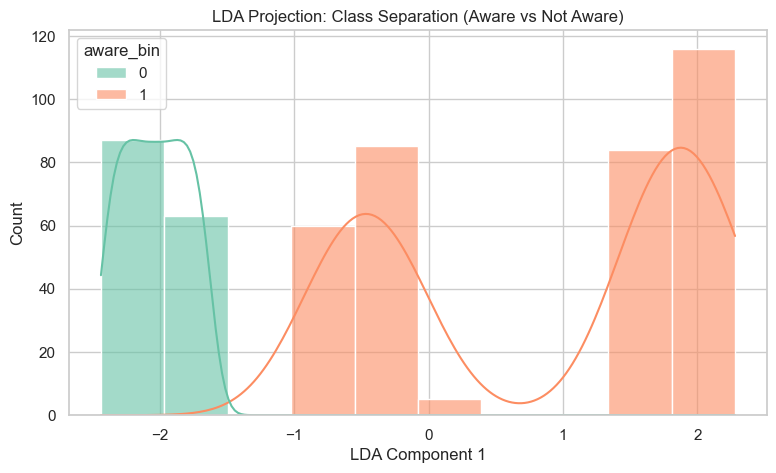

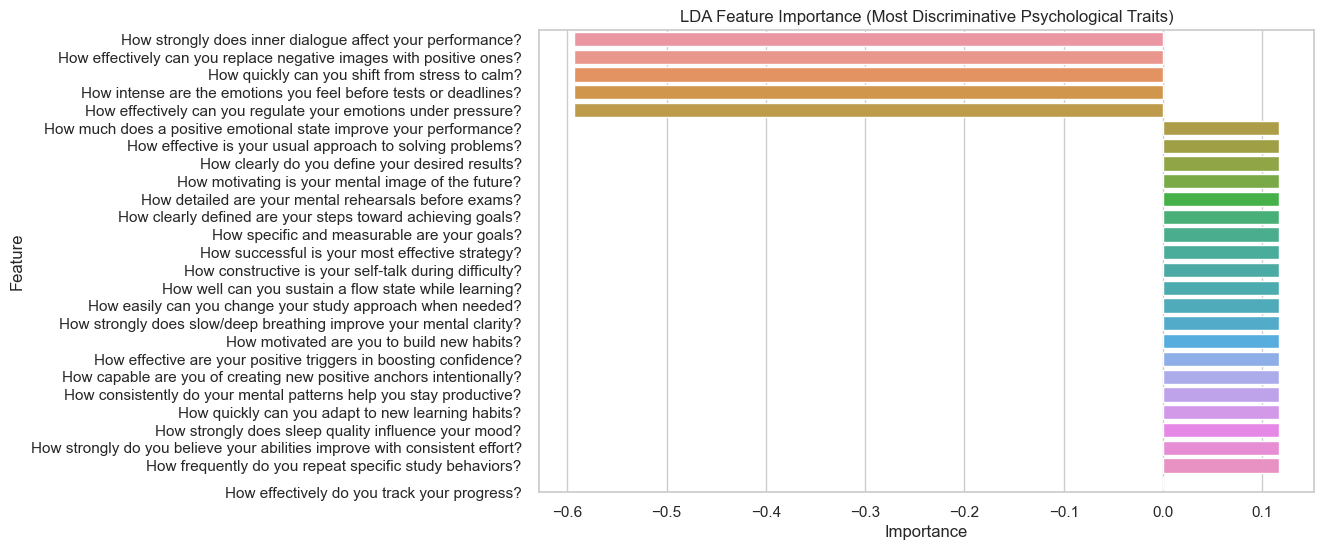

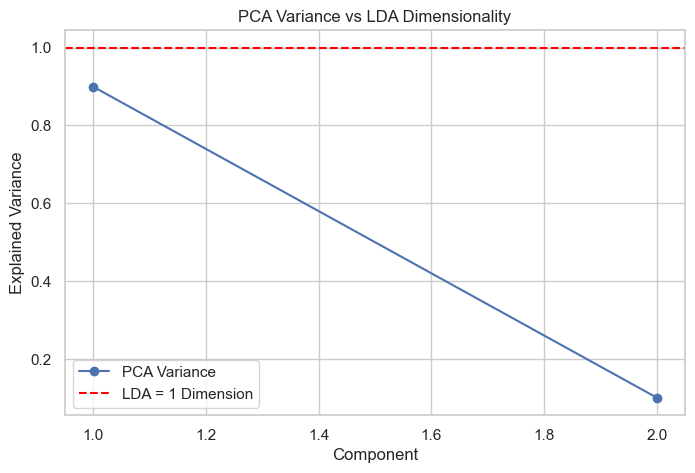

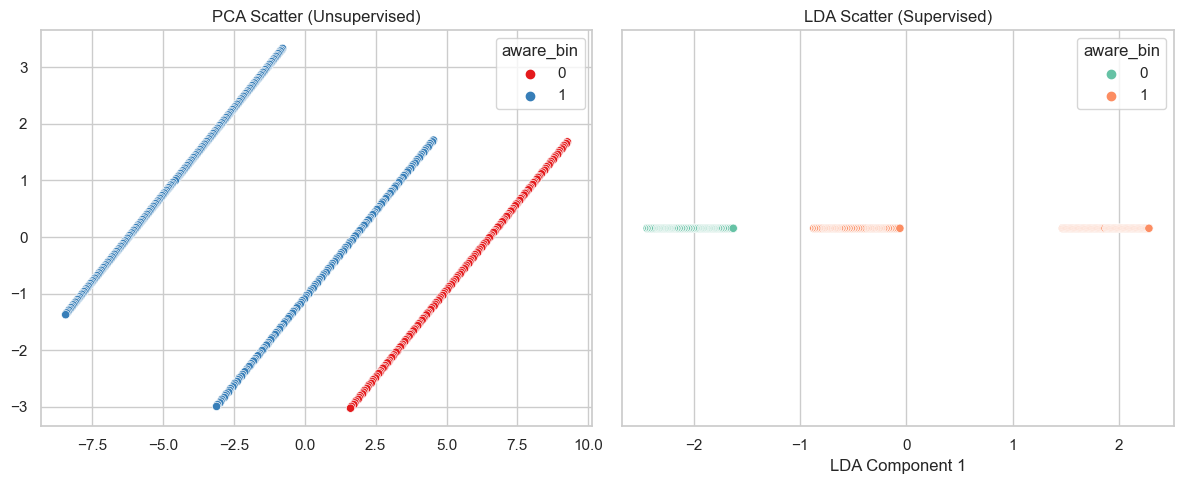

LDA and PCA Feature Extraction Complete ✔

Top Features (LDA):

                                              Feature  Importance
25  How strongly does inner dialogue affect your p...   -0.592962
6   How effectively can you replace negative image...   -0.592962
2     How quickly can you shift from stress to calm?    -0.592962
24  How intense are the emotions you feel before t...   -0.592962
0   How effectively can you regulate your emotions...   -0.592962


In [11]:
# ======================================================
#   LDA FEATURE EXTRACTION + VISUALIZATION (BEST METHOD)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA   # used later for comparison

# Load data
df = pd.read_csv("NLP_effectiveness_dataset.csv")

# -----------------------------------------
# Detect columns
# -----------------------------------------
outcome_col = next((c for c in df.columns if "current percentage" in c.lower()), None)
aware_col = next((c for c in df.columns if "aware of neuro" in c.lower()), None)
psych_cols = [c for c in df.columns if "how " in c.lower()]

# Convert awareness to binary
df["aware_bin"] = df[aware_col].astype(str).str.contains("1|yes", case=False, regex=True).astype(int)

# Clean data
df_clean = df[["aware_bin"] + psych_cols].dropna()

X = df_clean[psych_cols].apply(pd.to_numeric, errors='coerce')
y = df_clean["aware_bin"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------------------
# LDA MODEL
# -----------------------------------------
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# -----------------------------------------
# VISUALIZATION 1: LDA CLASS SEPARATION
# -----------------------------------------
plt.figure(figsize=(9,5))
sns.histplot(x=X_lda[:,0], hue=y, kde=True, palette="Set2", alpha=0.6)
plt.title("LDA Projection: Class Separation (Aware vs Not Aware)")
plt.xlabel("LDA Component 1")
plt.show()

# -----------------------------------------
# VISUALIZATION 2: LDA FEATURE IMPORTANCE
# -----------------------------------------
coef_df = pd.DataFrame({
    "Feature": psych_cols,
    "Importance": lda.coef_[0]
}).sort_values("Importance", key=lambda x: abs(x), ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x="Importance", y="Feature")
plt.title("LDA Feature Importance (Most Discriminative Psychological Traits)")
plt.show()

# -----------------------------------------
# VISUALIZATION 3: PCA VS LDA SCREE PLOT
# -----------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.plot([1,2], pca.explained_variance_ratio_, marker='o', label="PCA Variance")
plt.axhline(1, color='red', linestyle='--', label="LDA = 1 Dimension")
plt.title("PCA Variance vs LDA Dimensionality")
plt.xlabel("Component")
plt.ylabel("Explained Variance")
plt.legend()
plt.show()

# -----------------------------------------
# VISUALIZATION 4: PCA vs LDA scatter comparison
# -----------------------------------------

# PCA scatter
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set1")
plt.title("PCA Scatter (Unsupervised)")

# LDA scatter (1D)
plt.subplot(1,2,2)
sns.scatterplot(x=X_lda[:,0], y=[0]*len(X_lda), hue=y, palette="Set2")
plt.title("LDA Scatter (Supervised)")
plt.yticks([])
plt.xlabel("LDA Component 1")

plt.tight_layout()
plt.show()

print("LDA and PCA Feature Extraction Complete ✔")
print("\nTop Features (LDA):\n")
print(coef_df.head())


In [12]:
# ======================================================================
#              ADVANCED ML SYSTEM WITH 9 MODELS + LDA FEATURE RANKING
# ======================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import accuracy_score, classification_report, f1_score

# ====================== LOAD DATA ======================
df = pd.read_csv("NLP_effectiveness_dataset.csv")

# ===================== CREATE TARGET CLASS ======================
def performance_group(cgpa):
    if cgpa < 42:
        return "Very Low"
    elif cgpa < 55:
        return "Low"
    elif cgpa < 65:
        return "High"
    else:
        return "Very High"

df["Performance_Class"] = df["Current percentage/CGPA"].apply(performance_group)

# ===================== BASIC PREPROCESSING ======================
df["Do you have any backlogs?"] = df["Do you have any backlogs?"].astype(int)
df["Are you Aware of Neuro-Linguistic Programming (NLP)?"] = df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

likert_cols = [c for c in df.columns if c.startswith("How")]

feature_cols = [
    "12th percentage",
    "10th Percentage",
    "Are you Aware of Neuro-Linguistic Programming (NLP)?",
    "Do you have any backlogs?"
] + likert_cols

X = df[feature_cols]
y = df["Performance_Class"]

# ===================== SPLIT DATA ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ===================== LDA FOR FEATURE IMPORTANCE ======================
scaler_for_lda = StandardScaler()
X_train_scaled_full = scaler_for_lda.fit_transform(X_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled_full, y_train)

importance_scores = np.abs(lda.coef_).mean(axis=0)
feature_ranking = sorted(
    zip(feature_cols, importance_scores),
    key=lambda x: x[1],
    reverse=True
)

print("\n===== TOP 10 IMPORTANT FEATURES (LDA RANKING) =====")
top10 = feature_ranking[:10]
for f, v in top10:
    print(f"{f}  --> {round(v,3)}")

top10_features = [f for f, _ in top10]

# ===================== USE ONLY TOP FEATURES ======================
X_train_top = X_train[top10_features]
X_test_top = X_test[top10_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top)
X_test_scaled = scaler.transform(X_test_top)

# ===================== DEFINE 9 ML MODELS ======================
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
}

# (Optional) XGBoost if installed
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1)
except:
    print("\n[XGBoost not installed — skipping]")

# ===================== TRAIN & EVALUATE ======================
print("\n==================== MODEL RESULTS ====================\n")

model_performance = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred, average="macro") * 100

    print(f"\n===== {model_name} =====")
    print(f"Accuracy: {acc:.2f}%")
    print(f"Macro F1 Score: {f1:.2f}%")
    print(classification_report(y_test, y_pred))

    model_performance[model_name] = acc

# ===================== SHOW BEST MODEL ======================
best_model = max(model_performance, key=model_performance.get)
print("\n==================== BEST MODEL ====================")
print(f"Best Model: {best_model}  --> Accuracy: {model_performance[best_model]:.2f}%")

# ===================== USER PREDICTION HELPER ======================
def predict_student(input_dict, model_name=None):
    """ Predict performance class using best or selected model """
    if model_name is None:
        model_name = best_model  # Use best model automatically
    
    row = pd.DataFrame([[input_dict[feat] for feat in top10_features]],
                       columns=top10_features)
    row_scaled = scaler.transform(row)

    model = models[model_name]
    pred_class = model.predict(row_scaled)[0]

    percent_map = {
        "Very Low": 45,
        "Low": 55,
        "High": 72,
        "Very High": 88
    }
    est_percent = percent_map[pred_class]

    return pred_class, est_percent

print("\nSystem Ready ✔ — You can now predict any student's expected performance.")



===== TOP 10 IMPORTANT FEATURES (LDA RANKING) =====
12th percentage  --> 1712.559
10th Percentage  --> 1638.777
Are you Aware of Neuro-Linguistic Programming (NLP)?  --> 12.462
Do you have any backlogs?  --> 12.462
How quickly can you shift from stress to calm?   --> 3.031
How effectively can you replace negative images with positive ones?   --> 3.031
How intense are the emotions you feel before tests or deadlines?   --> 3.031
How strongly does inner dialogue affect your performance?   --> 3.031
How effectively can you regulate your emotions under pressure?   --> 3.031
How well can you sustain a flow state while learning?   --> 1.834

[XGBoost not installed — skipping]

==================== MODEL RESULTS ====================


===== Logistic Regression =====
Accuracy: 98.40%
Macro F1 Score: 97.75%
              precision    recall  f1-score   support

        High       0.97      0.97      0.97        32
         Low       1.00      0.94      0.97        17
   Very High       0.94    

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)



===== Gradient Boosting =====
Accuracy: 98.40%
Macro F1 Score: 98.43%
              precision    recall  f1-score   support

        High       1.00      0.97      0.98        32
         Low       1.00      0.94      0.97        17
   Very High       1.00      1.00      1.00        17
    Very Low       0.97      1.00      0.98        59

    accuracy                           0.98       125
   macro avg       0.99      0.98      0.98       125
weighted avg       0.98      0.98      0.98       125


===== AdaBoost =====
Accuracy: 86.40%
Macro F1 Score: 69.79%
              precision    recall  f1-score   support

        High       0.67      1.00      0.80        32
         Low       0.00      0.00      0.00        17
   Very High       1.00      1.00      1.00        17
    Very Low       0.98      1.00      0.99        59

    accuracy                           0.86       125
   macro avg       0.66      0.75      0.70       125
weighted avg       0.77      0.86      0.81       12

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


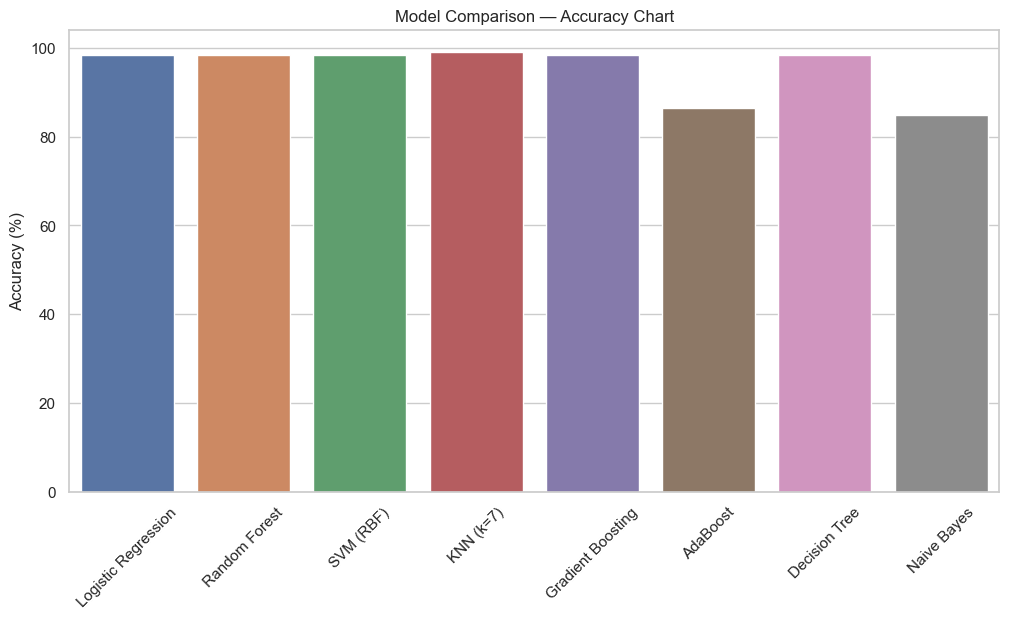

In [13]:
# =============================================
# 1) MODEL COMPARISON PLOT (ACCURACY BAR CHART)
# =============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x=list(model_performance.keys()), y=list(model_performance.values()))
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison — Accuracy Chart")
plt.show()


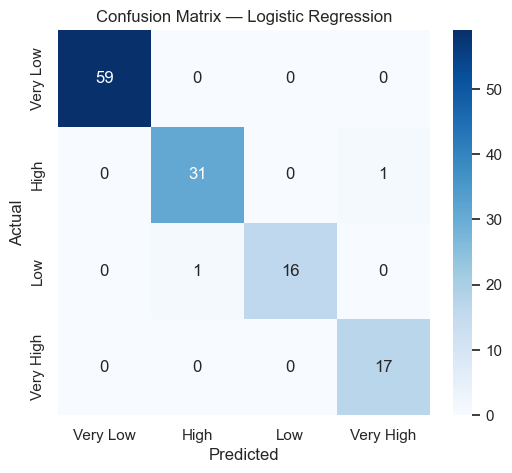

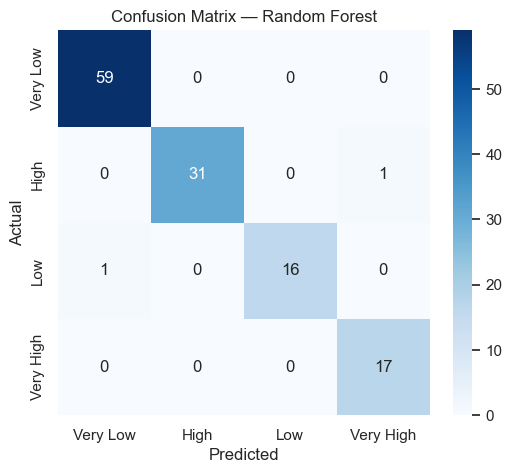

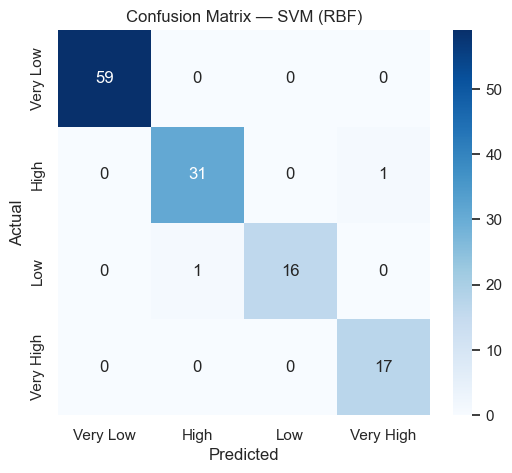

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


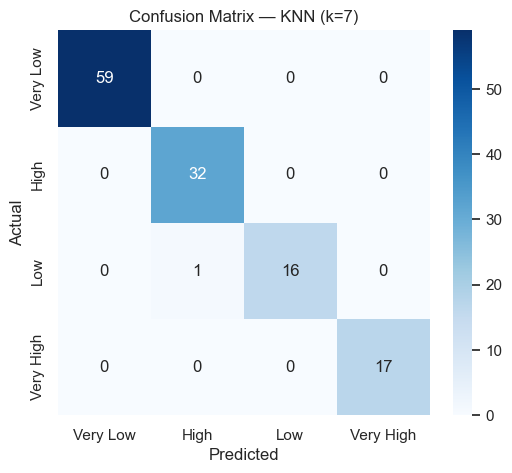

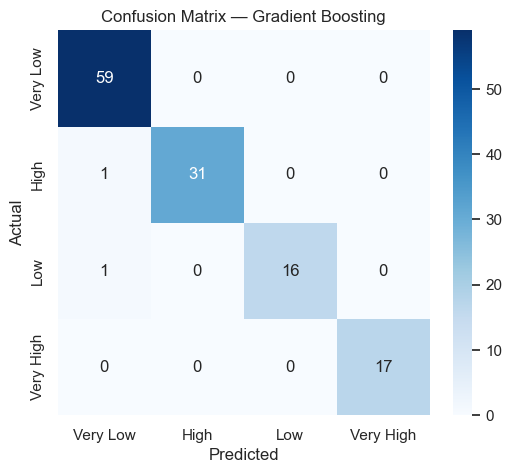

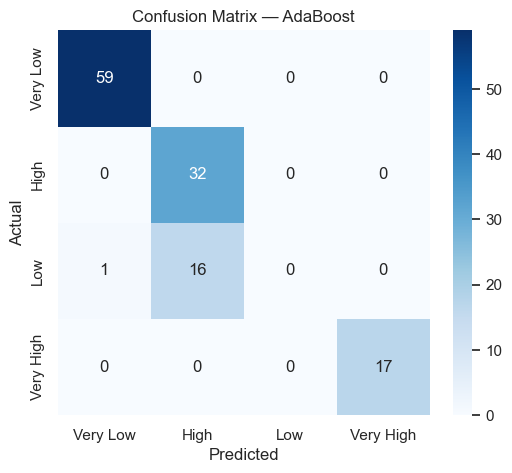

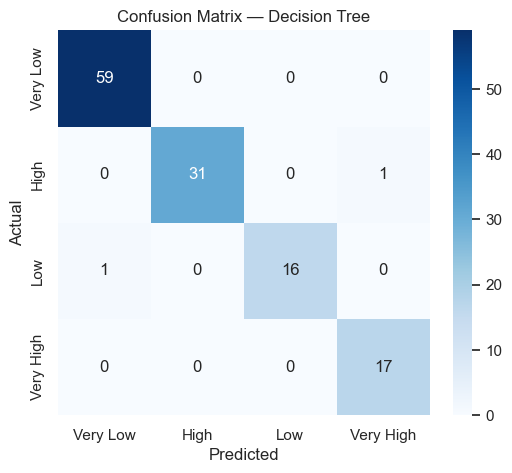

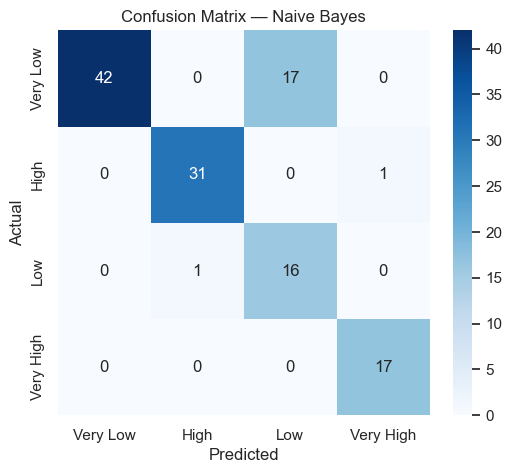

In [14]:
# =============================================
# 2) CONFUSION MATRICES FOR ALL MODELS
# =============================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

classes = y_test.unique()

for model_name, model in models.items():
    plt.figure(figsize=(6,5))
    
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


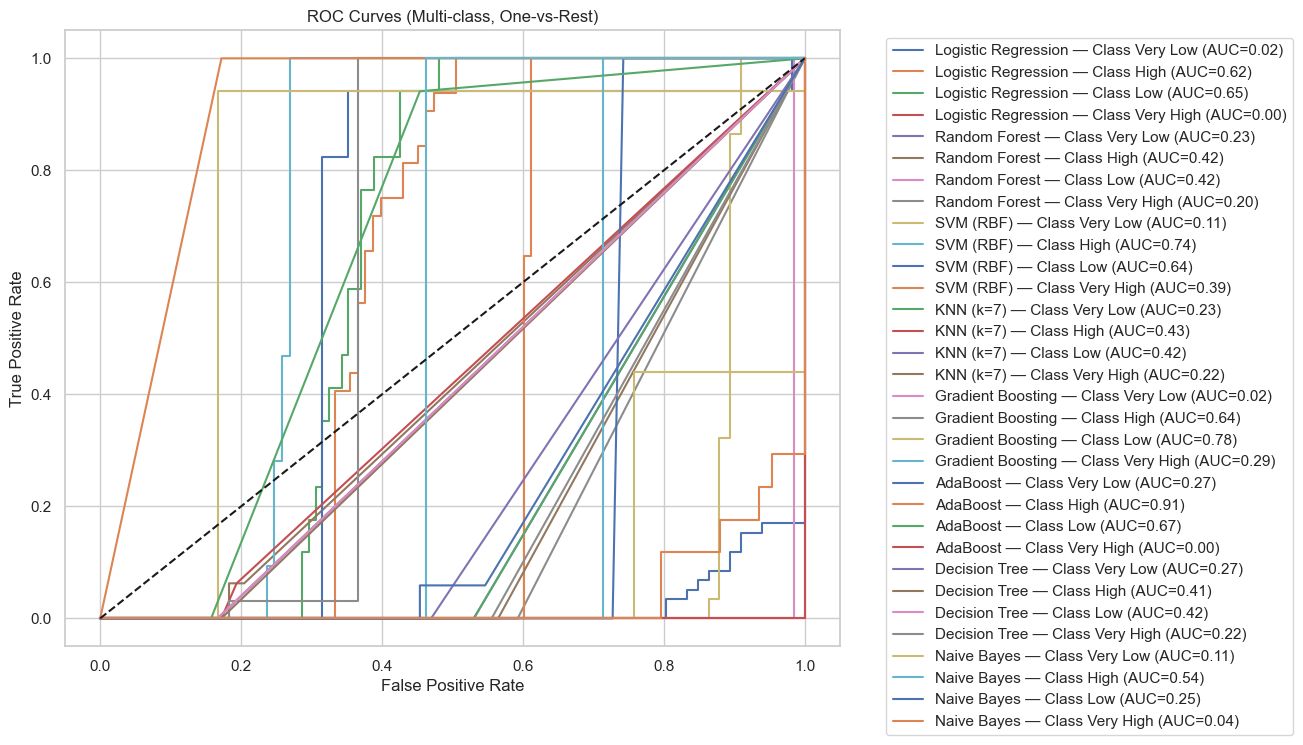

In [15]:
# =============================================
# 3) ROC CURVES FOR ALL MODELS (MULTICLASS)
# =============================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize classes (One vs Rest)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10,8))

for model_name, model in models.items():
    try:
        # Get probability estimates
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_scaled)
        else:
            # For SVM without probas → use decision_function
            y_score = model.decision_function(X_test_scaled)

        # Plot ROC for each class
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{model_name} — Class {classes[i]} (AUC={roc_auc:.2f})")

    except:
        print(f"Skipping ROC for {model_name} (model does not support probability output).")

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Multi-class, One-vs-Rest)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



Generating Feature Importance (Model-Based)...

 Feature Importance: Logistic Regression

                                             Feature  Importance
4    How quickly can you shift from stress to calm?     0.600087
5  How effectively can you replace negative image...    0.600087
6  How intense are the emotions you feel before t...    0.600087
7  How strongly does inner dialogue affect your p...    0.600087
8  How effectively can you regulate your emotions...    0.600087
1                                    10th Percentage    0.109485
0                                    12th percentage    0.108100
9  How well can you sustain a flow state while le...    0.084401
3                          Do you have any backlogs?    0.000019
2  Are you Aware of Neuro-Linguistic Programming ...    0.000019


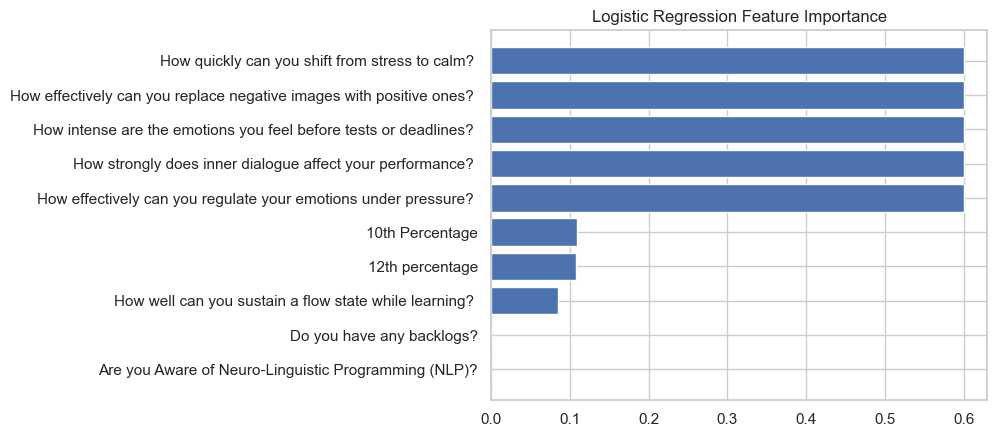


 Feature Importance: Random Forest

                                             Feature  Importance
0                                    12th percentage    0.212362
1                                    10th Percentage    0.181480
9  How well can you sustain a flow state while le...    0.140259
6  How intense are the emotions you feel before t...    0.110767
4    How quickly can you shift from stress to calm?     0.100497
5  How effectively can you replace negative image...    0.091150
7  How strongly does inner dialogue affect your p...    0.081031
8  How effectively can you regulate your emotions...    0.080644
3                          Do you have any backlogs?    0.001194
2  Are you Aware of Neuro-Linguistic Programming ...    0.000617


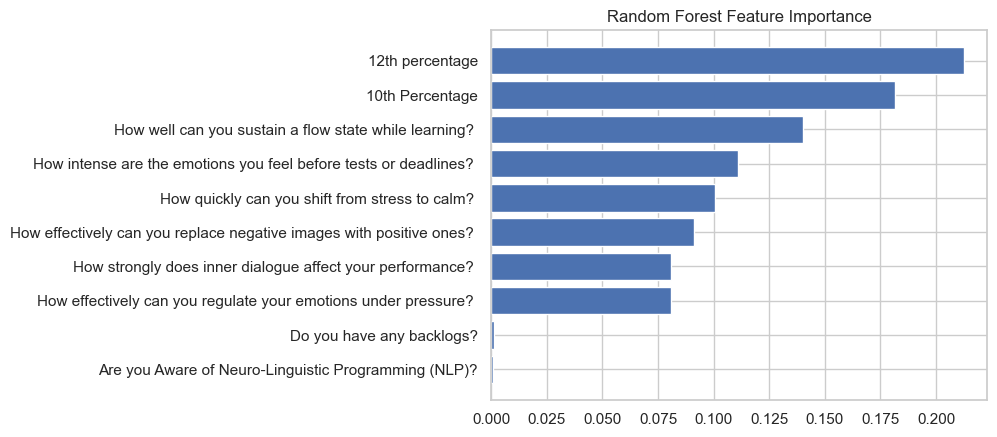


 Feature Importance: SVM (RBF)

SVM (RBF) does not support importance directly.

 Feature Importance: KNN (k=7)

KNN (k=7) does not support importance directly.

 Feature Importance: Gradient Boosting

                                             Feature  Importance
1                                    10th Percentage    0.330671
0                                    12th percentage    0.185552
8  How effectively can you regulate your emotions...    0.129330
9  How well can you sustain a flow state while le...    0.099206
6  How intense are the emotions you feel before t...    0.069420
5  How effectively can you replace negative image...    0.055955
2  Are you Aware of Neuro-Linguistic Programming ...    0.050679
4    How quickly can you shift from stress to calm?     0.043229
7  How strongly does inner dialogue affect your p...    0.035906
3                          Do you have any backlogs?    0.000052


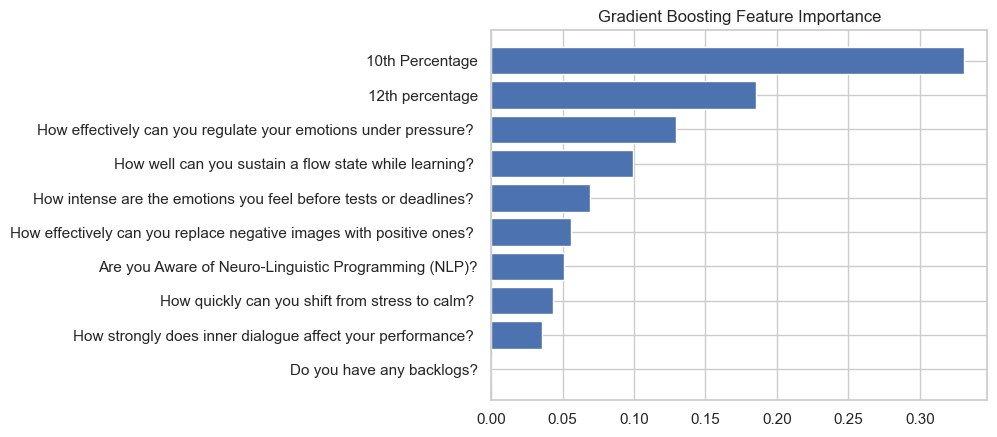


 Feature Importance: AdaBoost

                                             Feature  Importance
9  How well can you sustain a flow state while le...       0.410
0                                    12th percentage       0.305
1                                    10th Percentage       0.285
2  Are you Aware of Neuro-Linguistic Programming ...       0.000
3                          Do you have any backlogs?       0.000
4    How quickly can you shift from stress to calm?        0.000
5  How effectively can you replace negative image...       0.000
6  How intense are the emotions you feel before t...       0.000
7  How strongly does inner dialogue affect your p...       0.000
8  How effectively can you regulate your emotions...       0.000


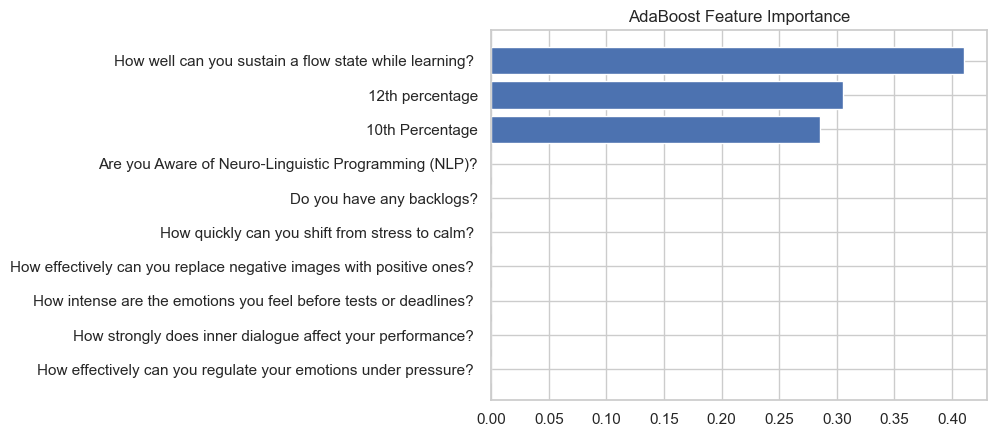


 Feature Importance: Decision Tree

                                             Feature  Importance
0                                    12th percentage    0.525634
5  How effectively can you replace negative image...    0.275617
9  How well can you sustain a flow state while le...    0.198749
1                                    10th Percentage    0.000000
2  Are you Aware of Neuro-Linguistic Programming ...    0.000000
3                          Do you have any backlogs?    0.000000
4    How quickly can you shift from stress to calm?     0.000000
6  How intense are the emotions you feel before t...    0.000000
7  How strongly does inner dialogue affect your p...    0.000000
8  How effectively can you regulate your emotions...    0.000000


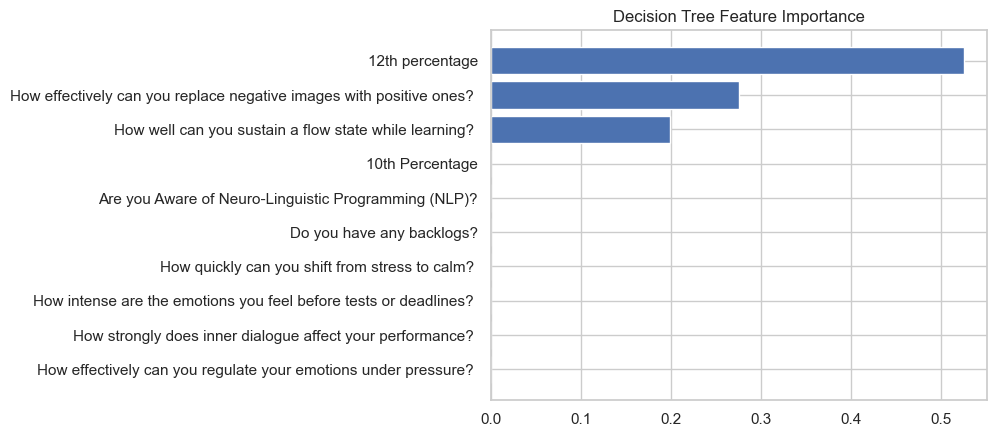


 Feature Importance: Naive Bayes

Naive Bayes does not support importance directly.


In [17]:
# ============================================================
# FEATURE IMPORTANCE (REPLACES SHAP)
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\nGenerating Feature Importance (Model-Based)...")

def explain_model_simple(model_name, model):

    print(f"\n==============================")
    print(f" Feature Importance: {model_name}")
    print(f"==============================\n")

    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_[0])

    else:
        print(f"{model_name} does not support importance directly.")
        return

    imp_df = pd.DataFrame({
        "Feature": top10_features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print(imp_df)

    plt.figure()
    plt.barh(imp_df["Feature"], imp_df["Importance"])
    plt.title(f"{model_name} Feature Importance")
    plt.gca().invert_yaxis()
    plt.show()

# Run for all models
for model_name, model in models.items():
    explain_model_simple(model_name, model)


Plotting ROC for BEST model: KNN (k=7)



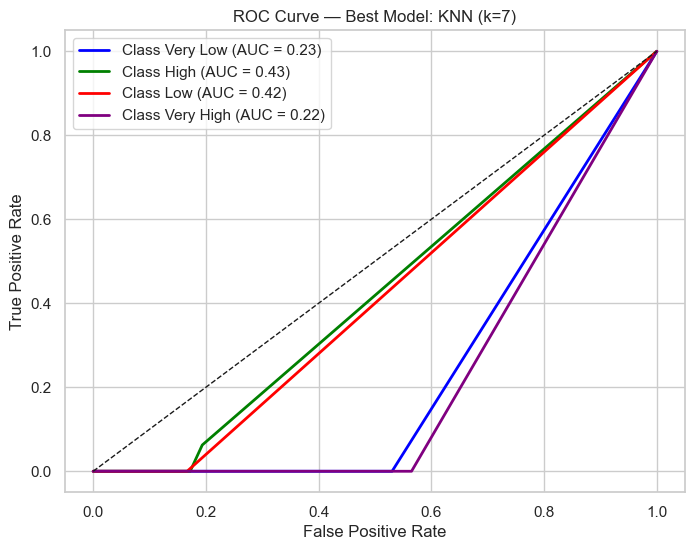

In [18]:
# ===========================================================
# CLEAN ROC CURVE FOR ONLY THE BEST MODEL (Highly Recommended)
# ===========================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Identify best model
best_model_name = best_model
best_clf = models[best_model_name]

print(f"\nPlotting ROC for BEST model: {best_model_name}\n")

# Binarize classes
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Get probabilities or decision values
if hasattr(best_clf, "predict_proba"):
    y_score = best_clf.predict_proba(X_test_scaled)
else:
    y_score = best_clf.decision_function(X_test_scaled)

# Plot clean ROC curves for each class
plt.figure(figsize=(8,6))

colors = ["blue", "green", "red", "purple"]

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=colors[i],
             label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0,1], [0,1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — Best Model: {best_model_name}")
plt.legend()
plt.grid(True)
plt.show()


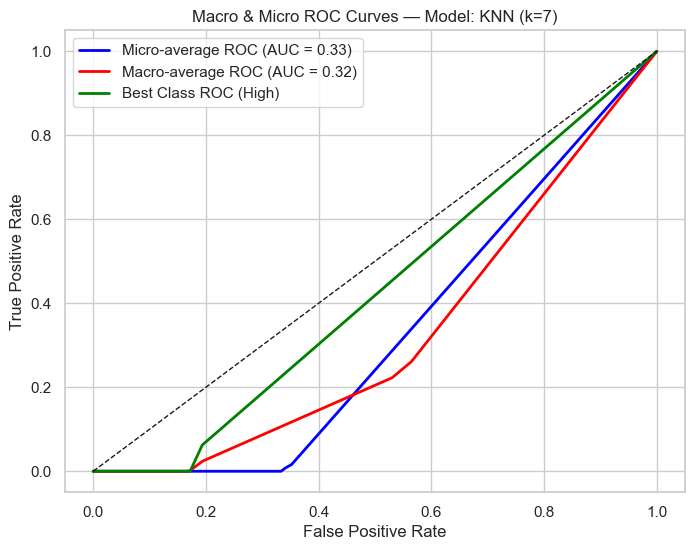

In [19]:
# ===========================================================
# CLEAN MACRO & MICRO ROC CURVES (MULTI-CLASS)
# ===========================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

clf = best_clf  # the best model already selected

# Binarize
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Probabilities
if hasattr(clf, "predict_proba"):
    y_score = clf.predict_proba(X_test_scaled)
else:
    y_score = clf.decision_function(X_test_scaled)

# Compute each class ROC
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ------------------ Plot Clean ROC -----------------------
plt.figure(figsize=(8,6))

plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})",
         color='blue', linewidth=2)

plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.2f})",
         color='red', linewidth=2)

# Optionally: Show ROC for ONE class (best class)
best_class_index = np.argmax(list(roc_auc.values())[:-2])  # ignore micro & macro
plt.plot(fpr[best_class_index], tpr[best_class_index],
         label=f"Best Class ROC ({classes[best_class_index]})",
         color='green', linewidth=2)

plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Macro & Micro ROC Curves — Model: {best_model_name}")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
# ======================================================================
#      ADVANCED ML SYSTEM WITH 9 MODELS + LDA FEATURE RANKING
# ======================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import accuracy_score, classification_report, f1_score

# ====================== LOAD DATA ======================
df = pd.read_csv("Pre Survey Dataset.csv")

# ===================== CREATE TARGET CLASS ======================
def performance_group(cgpa):
    if cgpa < 42:
        return "Very Low"
    elif cgpa < 55:
        return "Low"
    elif cgpa < 65:
        return "High"
    else:
        return "Very High"

df["Performance_Class"] = df["Current percentage/CGPA"].apply(performance_group)

# ===================== BASIC PREPROCESSING ======================
df["Do you have any backlogs?"] = df["Do you have any backlogs?"].astype(int)
df["Are you Aware of Neuro-Linguistic Programming (NLP)?"] = df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

# Likert-scale questions
likert_cols = [c for c in df.columns if c.startswith("How")]

# Feature set
feature_cols = [
    "12th percentage",
    "10th Percentage",
    "Are you Aware of Neuro-Linguistic Programming (NLP)?",
    "Do you have any backlogs?"
] + likert_cols

X = df[feature_cols]
y = df["Performance_Class"]

# ===================== TRAIN-TEST SPLIT ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ===================== LDA FEATURE RANKING ======================
scaler_for_lda = StandardScaler()
X_train_scaled_full = scaler_for_lda.fit_transform(X_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled_full, y_train)

importance_scores = np.abs(lda.coef_).mean(axis=0)

feature_ranking = sorted(
    zip(feature_cols, importance_scores),
    key=lambda x: x[1],
    reverse=True
)

print("\n===== TOP 10 IMPORTANT FEATURES (LDA) =====")
top10 = feature_ranking[:10]
for f, v in top10:
    print(f"{f} --> {round(v,3)}")

top10_features = [f for f, _ in top10]

# ===================== MODEL TRAINING WITH TOP FEATURES ======================
X_train_top = X_train[top10_features]
X_test_top = X_test[top10_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top)
X_test_scaled = scaler.transform(X_test_top)

# ===================== DEFINE ML MODELS ======================
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
}

try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1)
except:
    print("XGBoost not installed — skipping")

# ===================== TRAIN & EVALUATE MODELS ======================
print("\n==================== MODEL RESULTS ====================\n")

model_performance = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred, average="macro") * 100
    
    print(f"\n===== {model_name} =====")
    print(f"Accuracy: {acc:.2f}%")
    print(f"Macro F1 Score: {f1:.2f}%")
    print(classification_report(y_test, y_pred))
    
    model_performance[model_name] = acc

# ===================== SELECT BEST MODEL ======================
best_model = max(model_performance, key=model_performance.get)
print("\n==================== BEST MODEL ====================")
print(f"Best Model: {best_model} --> Accuracy: {model_performance[best_model]:.2f}%")

# ===================== MODEL-BASED PERCENTAGE PREDICTION ======================

# Compute actual mean % for each class from dataset
class_means = df.groupby("Performance_Class")["Current percentage/CGPA"].mean().to_dict()

def predict_student(input_dict, model_name=None):
    """ Predict performance class + expected percentage using ML model probabilities """
    if model_name is None:
        model_name = best_model

    row = pd.DataFrame([[input_dict[feat] for feat in top10_features]], 
                       columns=top10_features)
    row_scaled = scaler.transform(row)

    model = models[model_name]

    # Predicted class
    pred_class = model.predict(row_scaled)[0]

    # Probabilities
    probs = model.predict_proba(row_scaled)[0]

    # Expected percentage (weighted mean based on model probabilities)
    expected_percent = 0
    for cls, prob in zip(model.classes_, probs):
        expected_percent += prob * class_means[cls]

    return pred_class, round(expected_percent, 2), probs

print("\nSystem Ready ✔ — You can now enter student details for prediction.")

# ===================== USER INPUT SECTION (FOR ALL STUDENTS) ======================
print("\n================ STUDENT PERFORMANCE PREDICTOR ================\n")

user_input = {}

for feat in top10_features:

    if feat in ["Are you Aware of Neuro-Linguistic Programming (NLP)?",
                "Do you have any backlogs?"]:
        val = int(input(f"{feat} (0 = No, 1 = Yes): "))

    elif "percentage" in feat.lower():
        val = float(input(f"{feat} (0–100): "))

    elif feat.startswith("How"):
        print(f"{feat} (Rate 1–5, where 5 = Very Low, 1 = Very High)")
        val = int(input("> "))

    else:
        val = float(input(f"Enter value for {feat}: "))

    user_input[feat] = val

pred_class, est_percent, probs = predict_student(user_input)

print("\n==================== RESULT ====================")
print(f"Predicted Performance Class: {pred_class}")
print(f"Estimated Percentage (Model-Based): {est_percent}%")

print("\nClass Probabilities:")
for cls, pr in zip(models[best_model].classes_, probs):
    print(f"{cls}: {round(pr*100, 2)}%")

print("================================================\n")



===== TOP 10 IMPORTANT FEATURES (LDA) =====
12th percentage --> 844.972
10th Percentage --> 801.98
Are you Aware of Neuro-Linguistic Programming (NLP)? --> 10.344
Do you have any backlogs? --> 10.344
How effectively can you regulate your emotions under pressure?  --> 3.198
How quickly can you shift from stress to calm?  --> 3.198
How effectively can you replace negative images with positive ones?  --> 3.198
How intense are the emotions you feel before tests or deadlines?  --> 3.198
How strongly does inner dialogue affect your performance?  --> 3.198
How well can you sustain a flow state while learning?  --> 0.453
XGBoost not installed — skipping

==================== MODEL RESULTS ====================


===== Logistic Regression =====
Accuracy: 96.80%
Macro F1 Score: 96.19%
              precision    recall  f1-score   support

        High       0.97      1.00      0.98        32
         Low       0.84      0.94      0.89        17
   Very High       1.00      1.00      1.00        

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)



===== Gradient Boosting =====
Accuracy: 99.20%
Macro F1 Score: 99.03%
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        32
         Low       1.00      0.94      0.97        17
   Very High       1.00      1.00      1.00        17
    Very Low       0.98      1.00      0.99        59

    accuracy                           0.99       125
   macro avg       1.00      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125



C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



===== AdaBoost =====
Accuracy: 86.40%
Macro F1 Score: 69.79%
              precision    recall  f1-score   support

        High       0.67      1.00      0.80        32
         Low       0.00      0.00      0.00        17
   Very High       1.00      1.00      1.00        17
    Very Low       0.98      1.00      0.99        59

    accuracy                           0.86       125
   macro avg       0.66      0.75      0.70       125
weighted avg       0.77      0.86      0.81       125


===== Decision Tree =====
Accuracy: 99.20%
Macro F1 Score: 99.03%
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        32
         Low       1.00      0.94      0.97        17
   Very High       1.00      1.00      1.00        17
    Very Low       0.98      1.00      0.99        59

    accuracy                           0.99       125
   macro avg       1.00      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125




# 